<a href="https://colab.research.google.com/github/ronsong1234/Grand_IDC_Live/blob/main/notebooks/grandqc_slide_quality_with_idc_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Slide Quality Control with GrandQC and NCI Imaging Data Commons

Automated quality control (QC) is an essential preprocessing step in computational pathology pipelines. Artifacts such as tissue folds, out-of-focus regions, pen markings, and air bubbles can introduce noise that degrades the performance of downstream AI models.

[**GrandQC**](https://github.com/cpath-ukk/grandqc) is an open-source tool for automated tissue detection and multi-class artifact segmentation in whole slide images (WSIs). It was validated across slides from 19 international pathology departments and published in:

> Weng Z., Seper A., Pryalukhin A., et al. *GrandQC: A comprehensive solution to quality control problem in digital pathology.* Nature Communications 15, 10685 (2024). https://doi.org/10.1038/s41467-024-54769-y

[**NCI Imaging Data Commons (IDC)**](https://portal.imaging.datacommons.cancer.gov/) hosts ~100 TB of cancer imaging data, including thousands of H&E-stained whole slide images from TCGA, CPTAC, HTAN, and other programs — all stored as DICOM and freely accessible without authentication.

This notebook demonstrates how to:
1. **Discover** H&E-stained whole slide images in IDC using `idc-index`
2. **Set up** GrandQC and download its pre-trained models
3. **Download** slides from IDC and run GrandQC directly on DICOM files
4. **Visualize** tissue detection and artifact segmentation results
5. **Validate** the DICOM-based pipeline against GrandQC's pre-computed QC masks for the TCGA cohorts

> ⚠️ **Runtime requirement**: Run this notebook on a **T4 high-RAM** runtime. In Colab, select **Runtime → Change runtime type → T4 GPU** and enable the **High-RAM** option. The artifact-segmentation step needs the GPU for reasonable speed (~30–45 s/slide vs. 10–30 min/slide on CPU), and the high-RAM shape avoids out-of-memory errors when loading the larger whole-slide images.

## Disclaimer

The code and data of this repository are provided to promote reproducible research. They are not intended for clinical care or commercial use.

The software is provided "as is", without warranty of any kind, express or implied, including but not limited to the warranties of merchantability, fitness for a particular purpose and noninfringement. In no event shall the authors or copyright holders be liable for any claim, damages or other liability, whether in an action of contract, tort or otherwise, arising from, out of or in connection with the software or the use or other dealings in the software.

**GrandQC license**: Creative Commons Attribution-NonCommercial-ShareAlike 4.0 (CC BY-NC-SA 4.0). Non-commercial research use only; citation of the GrandQC paper is required.

## Part 1: Discover H&E Slides in IDC

IDC provides the `idc-index` Python package for querying slide metadata and downloading DICOM files. We start by installing it and exploring the available whole slide image collections.

In [1]:
%%capture
!pip install --upgrade idc-index wsidicom

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from IPython.display import IFrame, display
from idc_index import IDCClient

idc_client = IDCClient()
print(f"IDC data version: {idc_client.get_idc_version()}")

IDC data version: v24


### 1.1 Overview of Slide Microscopy Collections

IDC stores whole slide images using the DICOM Slide Microscopy (SM) standard. The `sm_index` table extends the main metadata index with pathology-specific attributes including staining protocol, tissue type, pixel spacing, and image dimensions.

In [3]:
# Load the slide microscopy index
idc_client.fetch_index("sm_index")

# Summary of all SM collections
sm_collections = idc_client.sql_query("""
    SELECT
        i.collection_id,
        COUNT(DISTINCT i.PatientID)      AS patients,
        COUNT(DISTINCT i.SeriesInstanceUID) AS series,
        ROUND(SUM(i.series_size_MB) / 1024.0, 1) AS size_GB,
        i.license_short_name
    FROM index i
    WHERE i.Modality = 'SM'
    GROUP BY i.collection_id, i.license_short_name
    ORDER BY patients DESC
""")

print(f"Total SM collections: {len(sm_collections)}")
print(f"Total SM series:      {sm_collections['series'].sum():,}")
print(f"Total size:           {sm_collections['size_GB'].sum():.0f} GB")
print()
sm_collections.head(15)

Total SM collections: 73
Total SM series:      76,299
Total size:           47871 GB



,collection_id,patients,series,size_GB,license_short_name
0,ccdi_mci,4407,4576,4548.0,CC BY 4.0
1,tcga_brca,1098,3111,1678.8,CC BY 3.0
2,gtex,971,25503,8354.2,CC BY 4.0
3,pdxnet,919,919,122.7,CC BY 4.0
4,tcga_gbm,607,2053,639.9,CC BY 3.0
5,tcga_ov,590,1481,476.5,CC BY 3.0
6,tcga_ucec,560,1371,1078.5,CC BY 3.0
7,tcga_kirc,537,2173,811.7,CC BY 3.0
8,tcga_hnsc,523,1263,560.5,CC BY 3.0
9,tcga_luad,522,1608,631.1,CC BY 3.0


### 1.2 Filter for H&E-Stained Slides

The `sm_index` table includes a `staining_usingSubstance_CodeMeaning` column (stored as an array) that records the staining protocol for each slide. We filter for slides stained with hematoxylin, which identifies H&E preparations.

In [4]:
# Count H&E slides per collection
he_by_collection = idc_client.sql_query("""
    SELECT
        i.collection_id,
        COUNT(DISTINCT i.PatientID)         AS patients,
        COUNT(DISTINCT i.SeriesInstanceUID) AS he_series,
        ROUND(SUM(i.series_size_MB) / 1024.0, 1) AS size_GB
    FROM index i
    JOIN sm_index s ON i.SeriesInstanceUID = s.SeriesInstanceUID
    WHERE array_to_string(s.staining_usingSubstance_CodeMeaning, ', ') LIKE '%hematoxylin%'
    GROUP BY i.collection_id
    ORDER BY he_series DESC
""")

print(f"Collections with H&E slides: {len(he_by_collection)}")
print(f"Total H&E series: {he_by_collection['he_series'].sum():,}")
he_by_collection.head(15)

Collections with H&E slides: 70
Total H&E series: 73,422


,collection_id,patients,he_series,size_GB
0,gtex,971,25503,8354.2
1,ccdi_mci,4401,4569,4545.8
2,tcga_brca,1098,3111,1678.8
3,tcga_kirc,537,2173,811.7
4,tcga_gbm,607,2053,639.9
5,tcga_lusc,504,1612,610.4
6,tcga_luad,522,1608,631.1
7,tcga_lgg,516,1572,1166.6
8,tcga_ov,590,1481,476.5
9,tcga_coad,460,1442,446.5


### 1.3 Select Slides for Quality Control

For this tutorial we work with slides from the [TCGA-BRCA](https://portal.imaging.datacommons.cancer.gov/explore/filters/?collection_id=tcga_brca) collection (The Cancer Genome Atlas — Breast Cancer). This collection is a good choice because:

- It contains over 3,000 H&E-stained slides
- GrandQC provides **pre-computed QC masks for the TCGA cohorts**, which we use to validate our DICOM-based run in Part 6

Those reference masks cover only the **diagnostic FFPE slides** (TCGA `DX` barcodes), not the frozen-section slides (`TS`/`BS`), so we deliberately select diagnostic slides here. We query the `sm_index` to retrieve per-slide metadata including the `ContainerIdentifier` (the original TCGA slide barcode), which we use to match IDC series against the pre-computed GrandQC masks.

In [5]:
# Query TCGA-BRCA H&E slides with key metadata
tcga_brca_he = idc_client.sql_query("""
    SELECT
        i.SeriesInstanceUID,
        i.PatientID,
        s.ContainerIdentifier,
        s.primaryAnatomicStructureModifier_CodeMeaning AS tissue_type,
        s.max_TotalPixelMatrixColumns                  AS width_px,
        s.max_TotalPixelMatrixRows                     AS height_px,
        s.min_PixelSpacing_2sf                         AS pixel_spacing_mm,
        s.ObjectiveLensPower                           AS objective_power,
        ROUND(i.series_size_MB, 1)                     AS size_MB
    FROM index i
    JOIN sm_index s ON i.SeriesInstanceUID = s.SeriesInstanceUID
    WHERE i.collection_id = 'tcga_brca'
      AND array_to_string(s.staining_usingSubstance_CodeMeaning, ', ') LIKE '%hematoxylin%'
    ORDER BY i.series_size_MB ASC
""")

print(f"TCGA-BRCA H&E slides: {len(tcga_brca_he)}")
print(f"Tissue types: {tcga_brca_he['tissue_type'].value_counts().to_dict()}")
print(f"\nSize range: {tcga_brca_he['size_MB'].min()} – {tcga_brca_he['size_MB'].max()} MB")
tcga_brca_he.head(10)

TCGA-BRCA H&E slides: 3111
Tissue types: {'Neoplasm, Primary': 2704, 'Normal': 399}

Size range: 9.1 – 3586.3 MB


,SeriesInstanceUID,PatientID,ContainerIdentifier,tissue_type,width_px,height_px,pixel_spacing_mm,objective_power,size_MB
0,1.3.6.1.4.1.5962.99.1.1247079754.248369703.163...,TCGA-A7-A26J,TCGA-A7-A26J-01B-02-BS2,"Neoplasm, Primary",8618,7243,0.00025,40,9.1
1,1.3.6.1.4.1.5962.99.1.1279025007.575797294.163...,TCGA-AC-A2QJ,TCGA-AC-A2QJ-11A-02-TS2,Normal,33993,6923,0.00050,20,15.5
2,1.3.6.1.4.1.5962.99.1.1306193840.1223239355.16...,TCGA-AC-A2FB,TCGA-AC-A2FB-11A-01-TSA,Normal,31993,7690,0.00050,20,16.5
3,1.3.6.1.4.1.5962.99.1.1263739509.328647659.163...,TCGA-BH-A5IZ,TCGA-BH-A5IZ-11A-01-TS1,Normal,20041,15048,0.00050,20,18.7
4,1.3.6.1.4.1.5962.99.1.1290706954.176399971.163...,TCGA-AC-A2QJ,TCGA-AC-A2QJ-11A-01-TS1,Normal,41991,9316,0.00050,20,22.8
5,1.3.6.1.4.1.5962.99.1.1315471301.865934712.163...,TCGA-E9-A1RF,TCGA-E9-A1RF-11A-03-TSC,Normal,27888,9784,0.00050,20,23.0
6,1.3.6.1.4.1.5962.99.1.1322835661.1509329658.16...,TCGA-GM-A2D9,TCGA-GM-A2D9-11A-02-TS2,Normal,35992,8945,0.00050,20,25.0
7,1.3.6.1.4.1.5962.99.1.1255105493.445850269.163...,TCGA-E9-A1RF,TCGA-E9-A1RF-11A-01-TSA,Normal,23904,14929,0.00050,20,26.9
8,1.3.6.1.4.1.5962.99.1.1247939226.656219549.163...,TCGA-OL-A5RW,TCGA-OL-A5RW-01Z-00-DX1,"Neoplasm, Primary",12879,13618,0.00050,<NA>,27.1
9,1.3.6.1.4.1.5962.99.1.1244105102.1853648157.16...,TCGA-E9-A1NF,TCGA-E9-A1NF-11A-05-TSE,Normal,13943,17330,0.00049,20,27.3


### 1.4 Select a Representative Set of Slides

For the hands-on GrandQC run we use a small set of **diagnostic (DX) H&E slides** that:
- are confirmed to have pre-computed GrandQC reference masks in the Zenodo `BRCA.tar` archive (so Part 6 can validate against them),
- span both magnifications GrandQC encounters in TCGA-BRCA (20× and 40×), and
- are small enough (≤ ~150 MB) for quick download and processing in a notebook.

All TCGA-BRCA diagnostic slides are primary-tumor sections, so the variety here comes from magnification rather than tissue type. The five barcodes below were verified against the Zenodo archive.

In [6]:
# Diagnostic (DX) H&E slides verified to have pre-computed GrandQC reference
# masks in the TCGA-BRCA archive on Zenodo (record 14041578). Every DX slide is
# primary tumor, so the variety here is in objective power (40x and 20x).
DEMO_BARCODES = [
    "TCGA-AC-A23G-01Z-00-DX1",  # 40x,  44 MB
    "TCGA-AC-A23C-01Z-00-DX1",  # 40x,  57 MB
    "TCGA-AC-A62V-01Z-00-DX1",  # 40x,  60 MB
    "TCGA-MS-A51U-01Z-00-DX1",  # 20x,  76 MB
    "TCGA-A8-A0AB-01Z-00-DX1",  # 20x, 151 MB
]

available = set(tcga_brca_he["ContainerIdentifier"])
present   = [b for b in DEMO_BARCODES if b in available]
missing   = [b for b in DEMO_BARCODES if b not in available]
if missing:
    print(f"WARNING: {len(missing)} barcode(s) not found in this IDC version: {missing}")

demo_slides = (
    tcga_brca_he[tcga_brca_he["ContainerIdentifier"].isin(present)]
    .drop_duplicates(subset="ContainerIdentifier")
    .set_index("ContainerIdentifier")
    .loc[present]                  # preserve our chosen order
    .reset_index()
)

print(f"Selected {len(demo_slides)} slides for GrandQC processing:")
display(
    demo_slides[[
        "PatientID", "ContainerIdentifier", "tissue_type",
        "objective_power", "width_px", "height_px", "size_MB"
    ]]
)

Selected 5 slides for GrandQC processing:


,PatientID,ContainerIdentifier,tissue_type,objective_power,width_px,height_px,size_MB
0,TCGA-AC-A23G,TCGA-AC-A23G-01Z-00-DX1,"Neoplasm, Primary",40,19920,18542,43.7
1,TCGA-AC-A23C,TCGA-AC-A23C-01Z-00-DX1,"Neoplasm, Primary",40,19920,26420,56.6
2,TCGA-AC-A62V,TCGA-AC-A62V-01Z-00-DX1,"Neoplasm, Primary",40,37410,18719,59.7
3,TCGA-MS-A51U,TCGA-MS-A51U-01Z-00-DX1,"Neoplasm, Primary",20,20000,23112,76.2
4,TCGA-A8-A0AB,TCGA-A8-A0AB-01Z-00-DX1,"Neoplasm, Primary",20,35584,42752,151.0


In [7]:
# Preview slides in the IDC SLIM viewer (pathology viewer)
for _, row in demo_slides.iterrows():
    url = idc_client.get_viewer_URL(seriesInstanceUID=row["SeriesInstanceUID"])
    print(f"{row['ContainerIdentifier']}  ({row['tissue_type']}, {row['size_MB']} MB)")
    print(f"  {url}")

TCGA-AC-A23G-01Z-00-DX1  (Neoplasm, Primary, 43.7 MB)
  https://viewer.imaging.datacommons.cancer.gov/slim/studies/2.25.50420347238962390240397469928564808838/series/1.3.6.1.4.1.5962.99.1.1231269212.1319310616.1637613841756.2.0
TCGA-AC-A23C-01Z-00-DX1  (Neoplasm, Primary, 56.6 MB)
  https://viewer.imaging.datacommons.cancer.gov/slim/studies/2.25.152145624386252553473554604280836097116/series/1.3.6.1.4.1.5962.99.1.1283257000.1868032442.1637665829544.2.0
TCGA-AC-A62V-01Z-00-DX1  (Neoplasm, Primary, 59.7 MB)
  https://viewer.imaging.datacommons.cancer.gov/slim/studies/2.25.241832143351794856972415812588470326610/series/1.3.6.1.4.1.5962.99.1.1364949850.1310426889.1637747522394.2.0
TCGA-MS-A51U-01Z-00-DX1  (Neoplasm, Primary, 76.2 MB)
  https://viewer.imaging.datacommons.cancer.gov/slim/studies/2.25.331833237758191447388107803597887857867/series/1.3.6.1.4.1.5962.99.1.1232545528.1025729098.1637615118072.2.0
TCGA-A8-A0AB-01Z-00-DX1  (Neoplasm, Primary, 151.0 MB)
  https://viewer.imaging.datac

## Part 2: GrandQC Setup

Before running GrandQC we need to:
1. Clone the repository from GitHub — we use the [`fedorov/grandqc`](https://github.com/fedorov/grandqc/tree/idc-dicom-fixes) fork, whose `idc-dicom-fixes` branch lets the inference scripts run directly on IDC DICOM series
2. Install its Python dependencies
3. Download the pre-trained models from Zenodo

> **Note**: The `idc-dicom-fixes` branch carries a handful of small, self-contained fixes on top of upstream `cpath-ukk/grandqc` — DICOM-directory input, compute-device auto-detection, a PyTorch ≥ 2.6 model-load fix, a small-slide overlay fix, and fail-loud error handling. None of them change model weights or algorithm logic (see Part 2.3 for the full list). Working from a fork keeps the notebook clean instead of monkey-patching the scripts at runtime.

### 2.1 Clone and Install Dependencies

In [8]:
%%capture
# Clone the IDC-patched GrandQC fork (branch idc-dicom-wsidicom, shallow clone).
# This branch builds on idc-dicom-fixes (the fixes that let the inference scripts
# run directly on IDC DICOM series) and adds one further change: it reads DICOM
# slides through wsidicom instead of OpenSlide, working around an OpenSlide 4.0.1
# bug that mis-decodes YBR_ICT JPEG 2000 frames (see Part 2.3). Point the clone
# back at idc-dicom-fixes to restore the OpenSlide reader once that bug is fixed
# upstream.
!git clone --depth 1 --branch idc-dicom-wsidicom https://github.com/fedorov/grandqc.git

# Install GrandQC Python dependencies.
# PyTorch is already present in Colab; we install the remaining packages.
# segmentation-models-pytorch 0.3.1 is pinned because its model.predict() API
# was removed in 0.4.0 and GrandQC relies on it. wsidicom provides the DICOM
# reader used in place of OpenSlide.
!pip install -q \
    "segmentation-models-pytorch==0.3.1" \
    "rasterio>=1.3" \
    "imagecodecs" \
    "zarr<3" \
    "tifffile" \
    "wsidicom"

### 2.2 Download Pre-trained Models

In [9]:
import os
import urllib.request

GRANDQC_SCRIPTS = "grandqc/01_WSI_inference_OPENSLIDE_QC"
MODELS_TD = os.path.join(GRANDQC_SCRIPTS, "models", "td")
MODELS_QC = os.path.join(GRANDQC_SCRIPTS, "models", "qc")
os.makedirs(MODELS_TD, exist_ok=True)
os.makedirs(MODELS_QC, exist_ok=True)

# (destination, source URL). Fetched with urllib.request so the cell runs the same
# on Windows, macOS and Linux — the shell wget used previously is not on Windows.
MODELS = [
    # Tissue detection model (~27 MB) — Zenodo record 14507273
    (os.path.join(MODELS_TD, "Tissue_Detection_MPP10.pth"),
     "https://zenodo.org/records/14507273/files/Tissue_Detection_MPP10.pth?download=1"),
    # Artifact segmentation model at MPP=1.5 (~25 MB) — Zenodo record 14041538.
    # MPP=1.5 (≈7× objective) is the recommended default for most scanners.
    (os.path.join(MODELS_QC, "GrandQC_MPP15.pth"),
     "https://zenodo.org/records/14041538/files/GrandQC_MPP15.pth?download=1"),
]

for dest, url in MODELS:
    # Skip a model that is already downloaded so re-running the cell is cheap.
    if os.path.exists(dest) and os.path.getsize(dest) > 1024 ** 2:
        print(f"Already present, skipping: {dest}")
        continue
    print(f"Downloading {os.path.basename(dest)} ...")
    urllib.request.urlretrieve(url, dest)

print()
print("Models downloaded:")
for dest, _ in MODELS:
    size_mb = os.path.getsize(dest) / 1024 ** 2
    print(f"  {dest}  ({size_mb:.1f} MB)")


Models downloaded:
  grandqc/01_WSI_inference_OPENSLIDE_QC/models/td/Tissue_Detection_MPP10.pth  (25.4 MB)
  grandqc/01_WSI_inference_OPENSLIDE_QC/models/qc/GrandQC_MPP15.pth  (24.2 MB)


### 2.3 Fixes Included in the Fork

The upstream GrandQC inference scripts assume conventional single-file WSIs on an NVIDIA GPU. Running them directly on IDC DICOM series needs a few small changes, already applied in the [`idc-dicom-wsidicom`](https://github.com/fedorov/grandqc/tree/idc-dicom-wsidicom) branch cloned above, which extends [`idc-dicom-fixes`](https://github.com/fedorov/grandqc/tree/idc-dicom-fixes) with a wsidicom-based DICOM reader (first row below). **No model weights or algorithm logic are changed.**

| Fix | Scripts | Why it is needed |
|-----|---------|------------------|
| Read DICOM slides via **wsidicom** instead of OpenSlide | both | OpenSlide 4.0.1 mis-decodes `YBR_ICT` JPEG 2000 frames — it does not invert the irreversible color transform, so white background turns salmon and is then wrongly labelled as pen marks; wsidicom (like pydicom) decodes correctly |
| Accept DICOM **series directories** as slides | both | IDC stores each slide as a directory of `.dcm` files; upstream only accepted single files, so the slide list came out empty and nothing was processed |
| Auto-detect compute device (CUDA / MPS / CPU) | both | upstream hardcodes `'cuda'`, which crashes on CPU/Apple Silicon |
| `torch.load(..., weights_only=False)` for the QC model | `main.py` | PyTorch ≥ 2.6 changed the default and refuses to unpickle the model object |
| Crop the tissue-detection mask to the thumbnail size | `wsi_tis_detect.py` | small slides produce a sub-512 px MPP-10 thumbnail, which crashed `cv2.addWeighted` in the overlay step (left `tis_det_overlay/` empty) |
| Surface per-slide failures with a non-zero exit | both | upstream swallowed errors and exited `0`, so empty output looked like a successful run |

The cell below confirms these fixes are present in the cloned scripts.

In [10]:
from pathlib import Path

# Confirm the IDC fixes shipped in the cloned fork branch are present.
tis = Path(f"{GRANDQC_SCRIPTS}/wsi_tis_detect.py").read_text()
mn  = Path(f"{GRANDQC_SCRIPTS}/main.py").read_text()

checks = {
    "DICOM-directory input (wsi_tis_detect.py)":   "_iter_slides" in tis,
    "DICOM-directory input (main.py)":             "_iter_slides" in mn,
    "auto device select (wsi_tis_detect.py)":      "cuda.is_available" in tis,
    "auto device select (main.py)":                "cuda.is_available" in mn,
    "weights_only=False (main.py)":                "weights_only=False" in mn,
    "small-slide overlay crop (wsi_tis_detect.py)":"end_image[-height:, -width:]" in tis,
    "fail-loud exit (wsi_tis_detect.py)":          "sys.exit(1)" in tis,
    "fail-loud exit (main.py)":                    "sys.exit(1)" in mn,
    "wsidicom DICOM reader (wsi_tis_detect.py)":   "wsidicom_slide" in tis,
    "wsidicom DICOM reader (main.py)":             "wsidicom_slide" in mn,
}
for name, ok in checks.items():
    print(f"  [{'OK ' if ok else 'MISSING'}] {name}")

assert all(checks.values()), (
    "Expected GrandQC fixes are not all present — check that the clone used "
    "branch 'idc-dicom-wsidicom' of github.com/fedorov/grandqc."
)
print("\nAll expected fixes present — scripts are ready to run on IDC DICOM slides.")

  [OK ] DICOM-directory input (wsi_tis_detect.py)
  [OK ] DICOM-directory input (main.py)
  [OK ] auto device select (wsi_tis_detect.py)
  [OK ] auto device select (main.py)
  [OK ] weights_only=False (main.py)
  [OK ] small-slide overlay crop (wsi_tis_detect.py)
  [OK ] fail-loud exit (wsi_tis_detect.py)
  [OK ] fail-loud exit (main.py)
  [OK ] wsidicom DICOM reader (wsi_tis_detect.py)
  [OK ] wsidicom DICOM reader (main.py)

All expected fixes present — scripts are ready to run on IDC DICOM slides.


## Part 3: Download Slides from IDC

`idc_client.download_from_selection()` fetches DICOM files for the requested series and places each series in its own subdirectory named by `SeriesInstanceUID`.

After downloading we rename each subdirectory to its `ContainerIdentifier` (the original TCGA slide barcode). This ensures that GrandQC's output files and the pre-computed TCGA mask filenames are consistently keyed by the human-readable barcode rather than an opaque UID.

### 3.1 Download DICOM Series

In [11]:
SLIDE_DIR = "slides"
os.makedirs(SLIDE_DIR, exist_ok=True)

print(f"Downloading {len(demo_slides)} slides  →  {SLIDE_DIR}/")
print("(This may take a few minutes depending on file sizes and network speed)\n")

idc_client.download_from_selection(
    downloadDir=SLIDE_DIR,
    seriesInstanceUID=demo_slides["SeriesInstanceUID"].tolist(),
    dirTemplate="%SeriesInstanceUID",
)
print("\nDownload complete.")

(This may take a few minutes depending on file sizes and network speed)




Download complete.


### 3.2 Rename Series Directories to TCGA Barcodes

GrandQC uses the directory/file name as the key for all output files (tissue mask, QC map, overlay, TSV report row). By renaming each downloaded series directory from its `SeriesInstanceUID` to its `ContainerIdentifier` (TCGA barcode), we get:

- Human-readable output filenames (`TCGA-AC-A23G-01Z-00-DX1_mask.png` instead of a UID)
- Straightforward matching with GrandQC's pre-computed TCGA masks (Part 6), which embed the same barcode in their filename

In [12]:
import shutil

# Build SeriesInstanceUID → ContainerIdentifier map
uid_to_barcode = dict(zip(demo_slides["SeriesInstanceUID"], demo_slides["ContainerIdentifier"]))

# Rename each downloaded UID directory to its barcode. This is written to be
# safe to re-run, and to tolerate the download cell being re-run (which would
# re-create the UID directory next to an already-renamed barcode directory).
for uid, barcode in uid_to_barcode.items():
    src = os.path.join(SLIDE_DIR, uid)      # freshly downloaded, named by UID
    dst = os.path.join(SLIDE_DIR, barcode)  # renamed target, named by barcode

    if os.path.isdir(src) and os.path.isdir(dst):
        # Both present → the download cell was re-run after a previous rename.
        # The UID directory is a redundant copy of the same (immutable) series,
        # so drop it and keep the barcode directory downstream code expects.
        shutil.rmtree(src)
        print(f"  Removed duplicate UID dir; kept {barcode}")
    elif os.path.isdir(src):
        os.rename(src, dst)
        print(f"  {uid}  →  {barcode}")
    elif os.path.isdir(dst):
        print(f"  Already renamed: {barcode}")
    else:
        print(f"  WARNING: directory not found: {uid}")

print("\nSlide directories after renaming:")
for d in sorted(os.listdir(SLIDE_DIR)):
    dpath = os.path.join(SLIDE_DIR, d)
    if os.path.isdir(dpath):
        n = sum(1 for f in os.listdir(dpath) if f.lower().endswith(".dcm"))
        print(f"  {d}/  ({n} .dcm files)")

  1.3.6.1.4.1.5962.99.1.1231269212.1319310616.1637613841756.2.0  →  TCGA-AC-A23G-01Z-00-DX1
  1.3.6.1.4.1.5962.99.1.1283257000.1868032442.1637665829544.2.0  →  TCGA-AC-A23C-01Z-00-DX1
  1.3.6.1.4.1.5962.99.1.1364949850.1310426889.1637747522394.2.0  →  TCGA-AC-A62V-01Z-00-DX1
  1.3.6.1.4.1.5962.99.1.1232545528.1025729098.1637615118072.2.0  →  TCGA-MS-A51U-01Z-00-DX1
  1.3.6.1.4.1.5962.99.1.1343238082.2143638158.1637725810626.2.0  →  TCGA-A8-A0AB-01Z-00-DX1

Slide directories after renaming:
  TCGA-A8-A0AB-01Z-00-DX1/  (4 .dcm files)
  TCGA-AC-A23C-01Z-00-DX1/  (4 .dcm files)
  TCGA-AC-A23G-01Z-00-DX1/  (4 .dcm files)
  TCGA-AC-A62V-01Z-00-DX1/  (4 .dcm files)
  TCGA-MS-A51U-01Z-00-DX1/  (4 .dcm files)


### 3.3 Verify wsidicom Can Read the DICOM Files

We load the IDC DICOM WSIs with [wsidicom](https://github.com/imi-bigpicture/wsidicom), pointed at each series directory — it reconstructs the full resolution pyramid from the `.dcm` files that share a `SeriesInstanceUID`.

We use wsidicom rather than OpenSlide because OpenSlide 4.0.1 (the current `openslide-bin`) mis-decodes JPEG 2000 frames whose `PhotometricInterpretation` is `YBR_ICT`: it does not invert the irreversible color transform, turning the white background salmon and the tissue blue-grey. Many IDC microscopy slides — including these TCGA-BRCA ones — are stored that way, and the corrupted colors would otherwise be mislabelled as pen marks downstream. wsidicom (like pydicom) inverts the transform correctly. See Part 2.3 for the fork change that routes the whole pipeline through wsidicom.

In [13]:
import wsidicom
from wsidicom import WsiDicom

print(f"wsidicom version: {wsidicom.__version__}\n")

for barcode in uid_to_barcode.values():
    slide_dir = os.path.join(SLIDE_DIR, barcode)
    dcm_files = sorted(f for f in os.listdir(slide_dir) if f.lower().endswith(".dcm"))
    if not dcm_files:
        print(f"  {barcode}: no .dcm files found")
        continue
    try:
        slide = WsiDicom.open(slide_dir)
        w, h = slide.size.width, slide.size.height
        mpp = round(slide.mpp.width, 4) if slide.mpp else "N/A"
        vendor = getattr(slide.metadata.equipment, "manufacturer", None) or "N/A"
        print(f"  {barcode}")
        print(f"    {w:,} × {h:,} px  |  MPP={mpp}  |  vendor={vendor}  |  levels={len(slide.levels)}")
        slide.close()
    except Exception as exc:
        print(f"  {barcode}: ERROR — {exc}")

print("\nAll slides verified.")

wsidicom version: 0.33.1

  TCGA-AC-A23G-01Z-00-DX1
    19,920 × 18,542 px  |  MPP=0.2457  |  vendor=Leica Biosystems  |  levels=3
  TCGA-AC-A23C-01Z-00-DX1
    19,920 × 26,420 px  |  MPP=0.2457  |  vendor=Leica Biosystems  |  levels=3
  TCGA-AC-A62V-01Z-00-DX1
    37,410 × 18,719 px  |  MPP=0.252  |  vendor=Leica Biosystems  |  levels=3
  TCGA-MS-A51U-01Z-00-DX1
    20,000 × 23,112 px  |  MPP=0.499  |  vendor=Leica Biosystems  |  levels=3
  TCGA-A8-A0AB-01Z-00-DX1
    35,584 × 42,752 px  |  MPP=0.2325  |  vendor=Carl Zeiss  |  levels=3

All slides verified.


## Part 4: Run GrandQC Quality Control

GrandQC runs as two sequential scripts, both inside `grandqc/01_WSI_inference_OPENSLIDE_QC/`:

| Step | Script | MPP | Time (GPU) | Output |
|------|--------|-----|------------|--------|
| 1 | `wsi_tis_detect.py` | 10 | ~0.4 s/slide | Binary tissue masks |
| 2 | `main.py` | 1.5 | ~30–45 s/slide | 7-class artifact maps, GeoJSON, TSV report |

The 7 artifact classes are: **1** clean tissue · **2** folds · **3** dark spots · **4** pen marks · **5** air bubbles/edges · **6** out-of-focus · **7** background.

Both scripts load models via relative paths (`./models/…`) and must therefore be invoked with their directory as the working directory. We use `subprocess` with `cwd=GRANDQC_SCRIPTS` to achieve this while keeping output streaming to the cell.

> **On inference resolution**: the artifact model runs at MPP 1.5 (≈7× objective), *not* at the slide's native 20×/40×, and the per-slide MPP is read from the DICOM `PixelSpacing` (surfaced by the wsidicom-backed reader as microns per pixel). For how this is controlled, the patch-size math, and an empirical confirmation on an IDC slide, see [`grandqc_slide_quality_resolution_notes.md`](grandqc_slide_quality_resolution_notes.md).

### 4.1 Step 1 — Tissue Detection

Produces a low-resolution binary mask (tissue vs. background) for each slide. The mask is saved as a PNG and re-used by Step 2 to skip background patches and cut inference time.

In [14]:
import subprocess, sys

OUTPUT_DIR = "qc_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

slide_dir_abs  = os.path.abspath(SLIDE_DIR)
output_dir_abs = os.path.abspath(OUTPUT_DIR)
scripts_abs    = os.path.abspath(GRANDQC_SCRIPTS)

print(f"Slides:          {slide_dir_abs}")
print(f"Output:          {output_dir_abs}")
print(f"Scripts dir:     {scripts_abs}")
print()
print("Running wsi_tis_detect.py ...")

result = subprocess.run(
    [sys.executable, "wsi_tis_detect.py",
     "--slide_folder", slide_dir_abs,
     "--output_dir",   output_dir_abs],
    cwd=scripts_abs,
)

if result.returncode != 0:
    print(f"\nERROR: wsi_tis_detect.py exited with code {result.returncode}")
else:
    mask_dir = os.path.join(output_dir_abs, "tis_det_mask")
    masks = sorted(os.listdir(mask_dir))
    print(f"\nTissue detection complete — {len(masks)} mask(s) written to {mask_dir}/")
    for m in masks:
        print(f"  {m}")

Slides:          /content/slides
Output:          /content/qc_output
Scripts dir:     /content/grandqc/01_WSI_inference_OPENSLIDE_QC

Running wsi_tis_detect.py ...

Tissue detection complete — 5 mask(s) written to /content/qc_output/tis_det_mask/
  TCGA-A8-A0AB-01Z-00-DX1_MASK.png
  TCGA-AC-A23C-01Z-00-DX1_MASK.png
  TCGA-AC-A23G-01Z-00-DX1_MASK.png
  TCGA-AC-A62V-01Z-00-DX1_MASK.png
  TCGA-MS-A51U-01Z-00-DX1_MASK.png


### 4.2 Step 2 — Artifact Segmentation

Runs the 7-class artifact model at MPP=1.5. For each slide it produces:

- `maps_qc/<barcode>_map_QC.png` — color-coded artifact map (same resolution as tissue mask)
- `overlays_qc/<barcode>_overlay_QC.jpg` — artifact map overlaid on a downscaled slide thumbnail
- `mask_qc/<barcode>_mask.png` — raw integer mask (class 1–7 per pixel)
- `geojson_qc/<barcode>.geojson` — polygon annotations compatible with QuPath and SLIM
- `report_qc_output_0_N_stats_per_slide.txt` — TSV with per-slide dimensions and processing time

> **GPU note**: On a T4 GPU (Colab free tier), expect ~30–45 s per slide. On CPU only, plan for 10–30 min per slide depending on size.

In [15]:
print("Running main.py (artifact segmentation) ...")

result = subprocess.run(
    [sys.executable, "main.py",
     "--slide_folder", slide_dir_abs,
     "--output_dir",   output_dir_abs,
     "--mpp_model",    "1.5",
     "--create_geojson", "Y"],
    cwd=scripts_abs,
)

if result.returncode != 0:
    print(f"\nERROR: main.py exited with code {result.returncode}")
else:
    maps_dir = os.path.join(output_dir_abs, "maps_qc")
    maps = sorted(os.listdir(maps_dir))
    print(f"\nArtifact segmentation complete — {len(maps)} map(s) in {maps_dir}/")
    for m in maps:
        print(f"  {m}")

    # Locate the TSV report (name includes the slide count)
    reports = [f for f in os.listdir(output_dir_abs) if f.endswith("_stats_per_slide.txt")]
    if reports:
        import pandas as pd
        report_path = os.path.join(output_dir_abs, reports[0])
        df = pd.read_csv(report_path, sep="\t")
        print(f"\nPer-slide report ({reports[0]}):")
        display(df[["slide_name", "mpp", "height", "width", "time"]])

Running main.py (artifact segmentation) ...

Artifact segmentation complete — 5 map(s) in /content/qc_output/maps_qc/
  TCGA-A8-A0AB-01Z-00-DX1_map_QC.png
  TCGA-AC-A23C-01Z-00-DX1_map_QC.png
  TCGA-AC-A23G-01Z-00-DX1_map_QC.png
  TCGA-AC-A62V-01Z-00-DX1_map_QC.png
  TCGA-MS-A51U-01Z-00-DX1_map_QC.png

Per-slide report (report_qc_output_0_5_stats_per_slide.txt):


,slide_name,mpp,height,width,time
0,TCGA-A8-A0AB-01Z-00-DX1,0.2325,39636,33030,2.3
1,TCGA-AC-A23C-01Z-00-DX1,0.2457,25000,18750,1.0
2,TCGA-AC-A23G-01Z-00-DX1,0.2457,15625,18750,0.6
3,TCGA-AC-A62V-01Z-00-DX1,0.2520,18282,36564,1.2
4,TCGA-MS-A51U-01Z-00-DX1,0.4990,23085,18468,0.3


## Part 5: Visualize and Analyze Results

GrandQC writes several output types per slide. We look at three of them:

1. **Tissue detection overlays** — confirms that tissue vs. background separation was correct
2. **Artifact segmentation maps** — color-coded composite of the 7-class artifact model overlaid on a slide thumbnail
3. **Raw integer masks** (`mask_qc/`) — pixel-level class labels (1–7) used to compute per-slide artifact fractions

### 5.1 Tissue Detection Overlays

Each overlay blends the original thumbnail (70 %) with a two-class color mask (30 %): blue = tissue, gray = background.

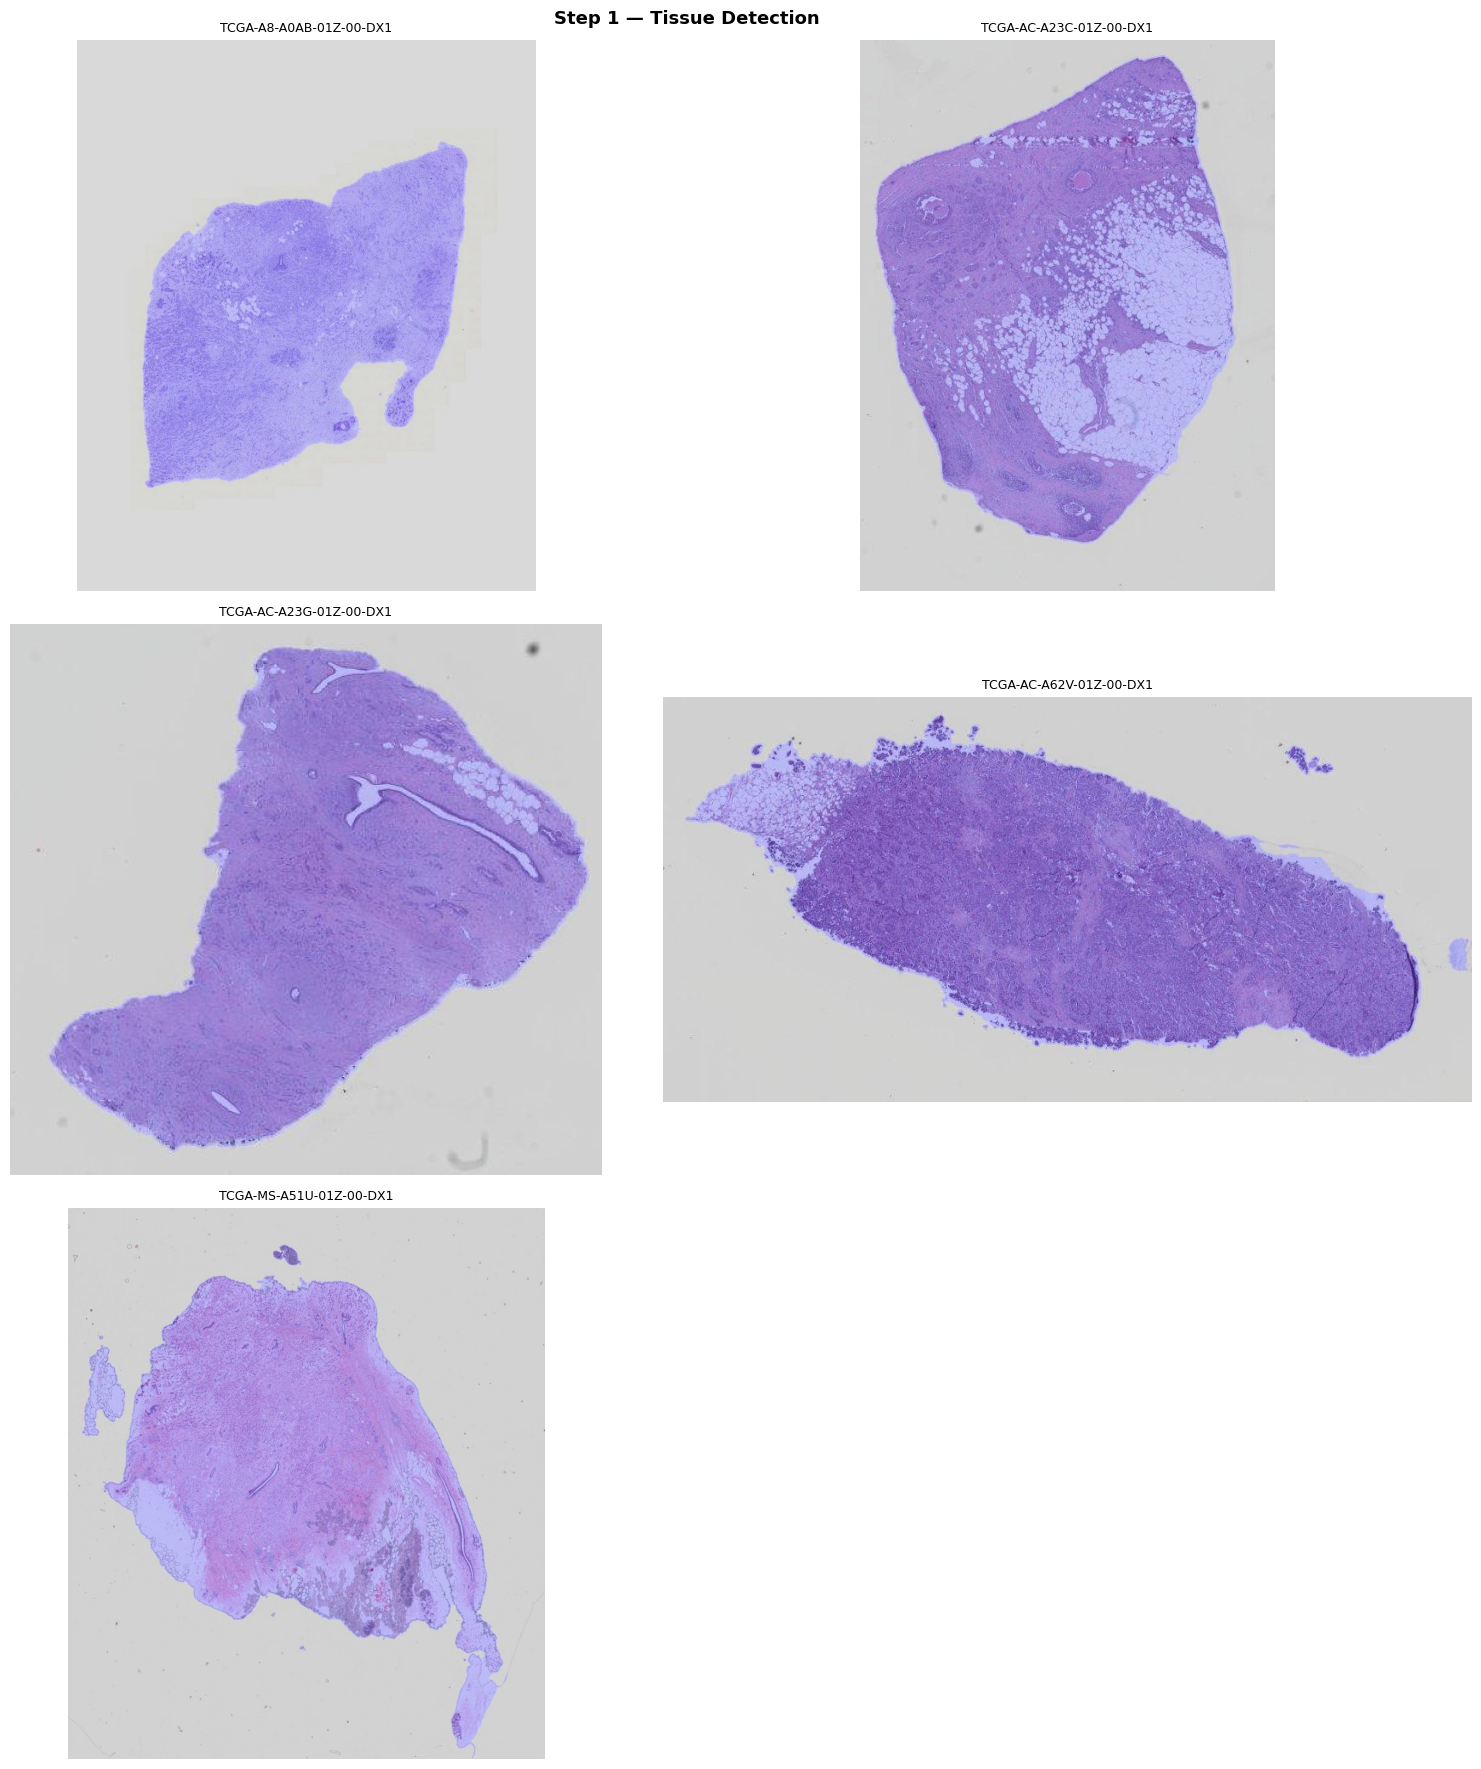

In [16]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

overlay_dir = os.path.join(OUTPUT_DIR, "tis_det_overlay")
fnames = sorted(os.listdir(overlay_dir))

# Lay panels out 2 per row so each image is large enough to inspect
ncols = 2 if len(fnames) > 1 else 1
nrows = (len(fnames) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(8 * ncols, 6 * nrows))
axes = np.array(axes).reshape(-1)

for ax, fname in zip(axes, fnames):
    ax.imshow(mpimg.imread(os.path.join(overlay_dir, fname)))
    ax.set_title(fname.replace("_OVERLAY.jpg", ""), fontsize=9)
    ax.axis("off")
for ax in axes[len(fnames):]:   # hide unused panels in the last row
    ax.axis("off")

plt.suptitle("Step 1 — Tissue Detection", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 5.2 Artifact Segmentation Maps

The QC overlay composites the artifact color map onto a downscaled thumbnail of the original slide. Colors match the `wsi_colors.py` palette used by GrandQC:

| Class | Color | Artifact |
|-------|-------|---------|
| 1 | ■ Gray `#808080` | Clean tissue |
| 2 | ■ Tomato `#FF6347` | Folds |
| 3 | ■ Lime `#00FF00` | Dark spots |
| 4 | ■ Red `#FF0000` | Pen marks |
| 5 | ■ Magenta `#FF00FF` | Air bubbles / slide edges |
| 6 | ■ Indigo `#4B0082` | Out-of-focus |
| 7 | □ White `#FFFFFF` | Background |

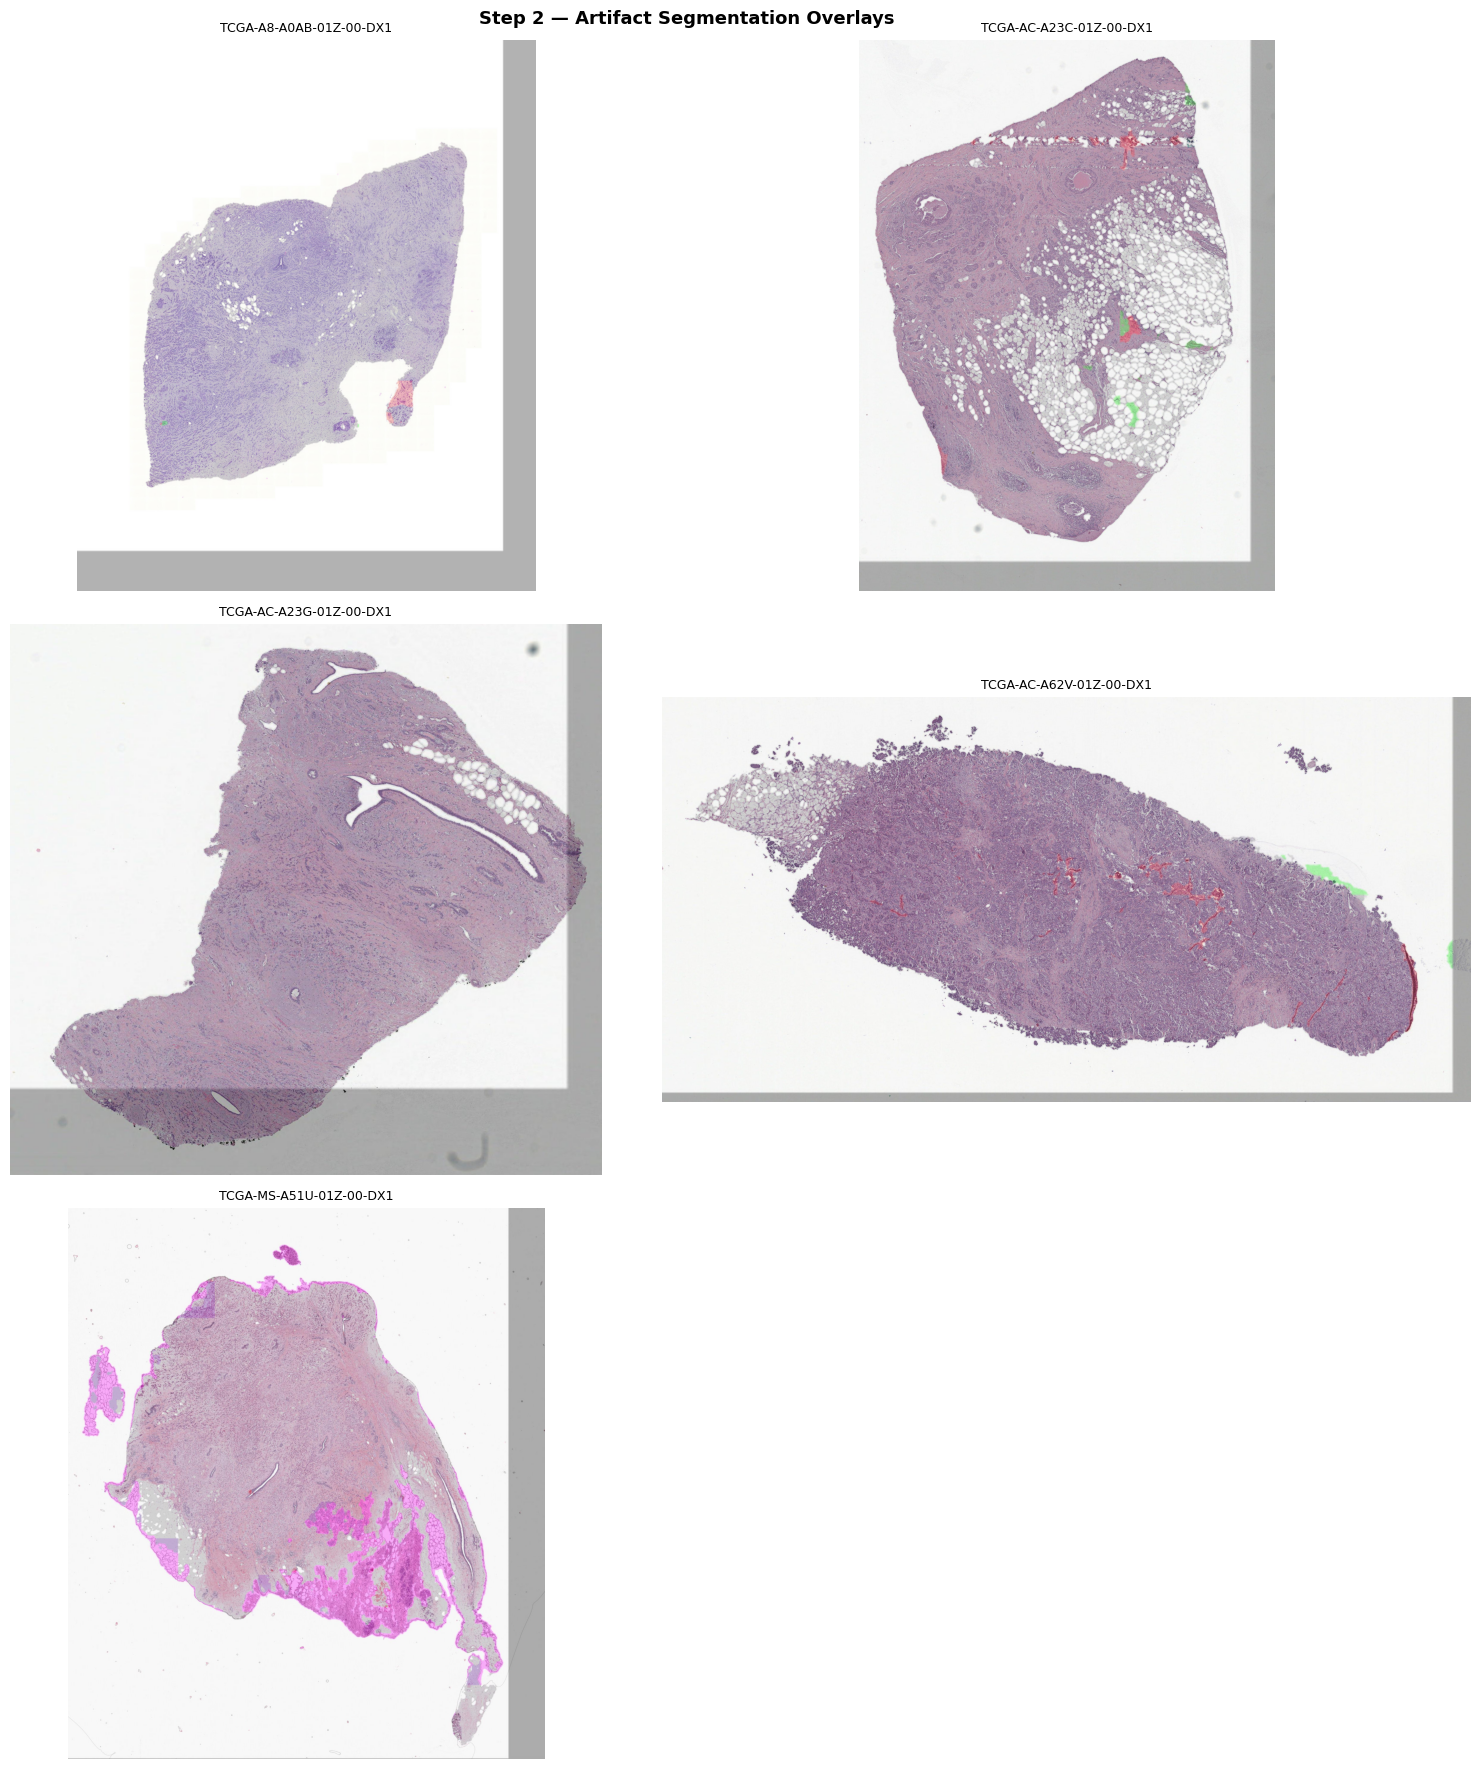

In [17]:
overlay_qc_dir = os.path.join(OUTPUT_DIR, "overlays_qc")
fnames_qc = sorted(os.listdir(overlay_qc_dir))

# Lay panels out 2 per row so each image is large enough to inspect
ncols = 2 if len(fnames_qc) > 1 else 1
nrows = (len(fnames_qc) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(8 * ncols, 6 * nrows))
axes = np.array(axes).reshape(-1)

for ax, fname in zip(axes, fnames_qc):
    ax.imshow(mpimg.imread(os.path.join(overlay_qc_dir, fname)))
    ax.set_title(fname.replace("_overlay_QC.jpg", ""), fontsize=9)
    ax.axis("off")
for ax in axes[len(fnames_qc):]:   # hide unused panels in the last row
    ax.axis("off")

plt.suptitle("Step 2 — Artifact Segmentation Overlays", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 5.3 Artifact Fractions per Slide

We read the raw integer masks from `mask_qc/` (pixel values 1–7) and compute what fraction of the **tissue area** (excluding background, class 7) belongs to each artifact class. This is the standard metric reported in the GrandQC paper.

Artifact class fractions (% of tissue area):


,Clean tissue,Folds,Dark spots,Pen marks,Bubbles/edges,Out-of-focus
slide,,,,,,
TCGA-A8-A0AB-01Z-00-DX1,67.0,0.5,0.0,0.0,0.0,0.0
TCGA-AC-A23C-01Z-00-DX1,79.9,0.5,0.5,0.2,0.0,0.0
TCGA-AC-A23G-01Z-00-DX1,64.9,0.0,0.0,0.0,0.0,0.0
TCGA-AC-A62V-01Z-00-DX1,88.5,1.5,0.4,0.0,0.0,0.0
TCGA-MS-A51U-01Z-00-DX1,66.0,0.0,0.0,0.0,15.4,1.7


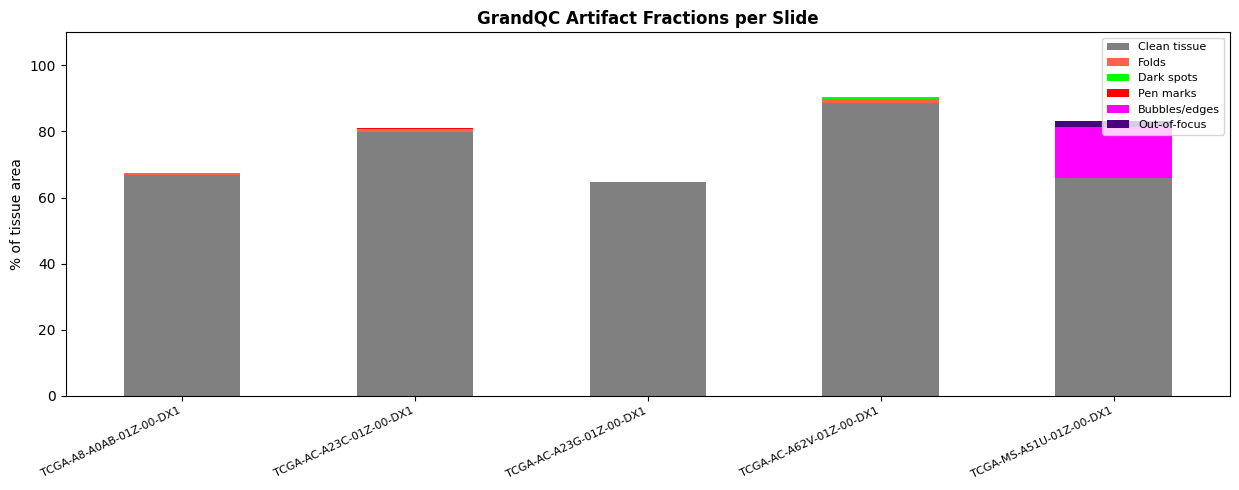

In [18]:
from PIL import Image

# GrandQC wsi_colors.py palette — RGB, indices 0-5 correspond to classes 1-6
GRANDQC_COLORS_RGB = [
    [128, 128, 128],  # 1 Clean tissue
    [255,  99,  71],  # 2 Folds
    [  0, 255,   0],  # 3 Dark spots
    [255,   0,   0],  # 4 Pen marks
    [255,   0, 255],  # 5 Bubbles/edges
    [ 75,   0, 130],  # 6 Out-of-focus
]
CLASS_NAMES_SHORT = [
    "Clean tissue", "Folds", "Dark spots",
    "Pen marks", "Bubbles/edges", "Out-of-focus",
]
# Normalize to [0,1] for matplotlib
mpl_colors = [[r/255, g/255, b/255] for r, g, b in GRANDQC_COLORS_RGB]

mask_dir = os.path.join(OUTPUT_DIR, "mask_qc")
rows = []
for fname in sorted(os.listdir(mask_dir)):
    barcode = fname.replace("_mask.png", "")
    mask = np.array(Image.open(os.path.join(mask_dir, fname)))
    tissue_px = np.sum(mask != 7)  # exclude background
    if tissue_px == 0:
        continue
    row = {"slide": barcode}
    for cls_idx, name in enumerate(CLASS_NAMES_SHORT, start=1):
        row[name] = np.sum(mask == cls_idx) / tissue_px * 100
    rows.append(row)

stats_df = pd.DataFrame(rows).set_index("slide")
print("Artifact class fractions (% of tissue area):")
display(stats_df.round(1))

# ── Stacked bar chart ────────────────────────────────────────────────────────
ax = stats_df[CLASS_NAMES_SHORT].plot(
    kind="bar",
    stacked=True,
    color=mpl_colors,
    figsize=(max(6, 2.5 * len(stats_df)), 5),
    edgecolor="none",
)
ax.set_ylabel("% of tissue area")
ax.set_xlabel("")
ax.set_title("GrandQC Artifact Fractions per Slide", fontweight="bold")
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha="right", fontsize=8)
ax.legend(loc="upper right", fontsize=8, framealpha=0.8)
ax.set_ylim(0, 110)
plt.tight_layout()
plt.show()

### 5.4 View Original Slides in IDC SLIM Viewer

The IDC SLIM viewer is a web-based pathology viewer for DICOM whole slide images. The links below open each slide at full resolution. The GeoJSON annotations produced by GrandQC (`geojson_qc/`) can be loaded into QuPath or other tools that accept GeoJSON overlays for interactive artifact review.

In [19]:
from IPython.display import IFrame, display

print("IDC SLIM viewer links (open in browser for full-resolution viewing):\n")
for _, row in demo_slides.iterrows():
    url = idc_client.get_viewer_URL(seriesInstanceUID=row["SeriesInstanceUID"])
    print(f"  {row['ContainerIdentifier']}")
    print(f"    {url}\n")

# Embed the first slide inline (750 px height)
first_url = idc_client.get_viewer_URL(seriesInstanceUID=demo_slides.iloc[0]["SeriesInstanceUID"])
print(f"Embedding: {demo_slides.iloc[0]['ContainerIdentifier']}")
display(IFrame(first_url, width="100%", height=750))

IDC SLIM viewer links (open in browser for full-resolution viewing):

  TCGA-AC-A23G-01Z-00-DX1
    https://viewer.imaging.datacommons.cancer.gov/slim/studies/2.25.50420347238962390240397469928564808838/series/1.3.6.1.4.1.5962.99.1.1231269212.1319310616.1637613841756.2.0

  TCGA-AC-A23C-01Z-00-DX1
    https://viewer.imaging.datacommons.cancer.gov/slim/studies/2.25.152145624386252553473554604280836097116/series/1.3.6.1.4.1.5962.99.1.1283257000.1868032442.1637665829544.2.0

  TCGA-AC-A62V-01Z-00-DX1
    https://viewer.imaging.datacommons.cancer.gov/slim/studies/2.25.241832143351794856972415812588470326610/series/1.3.6.1.4.1.5962.99.1.1364949850.1310426889.1637747522394.2.0

  TCGA-MS-A51U-01Z-00-DX1
    https://viewer.imaging.datacommons.cancer.gov/slim/studies/2.25.331833237758191447388107803597887857867/series/1.3.6.1.4.1.5962.99.1.1232545528.1025729098.1637615118072.2.0

  TCGA-A8-A0AB-01Z-00-DX1
    https://viewer.imaging.datacommons.cancer.gov/slim/studies/2.25.305523966109504368018

## Part 6: Validating the Pipeline Against Pre-computed TCGA Masks

In Parts 3–5 we ran GrandQC locally on IDC DICOM slides reading them through wsidicom — a path the GrandQC authors did not test in their original publication. Before using the pipeline on new data, it is good practice to verify that our results are consistent with the authors' reference outputs.

The GrandQC authors published pre-computed QC masks for the TCGA cohorts on Zenodo:

> **GrandQC pre-computed masks**: [zenodo.org/records/14041578](https://zenodo.org/records/14041578)  
> One tar archive per TCGA cohort (a few large cohorts are split into two parts), ~18 GB in total. The TCGA-BRCA archive (`BRCA.tar`) alone is ~2 GB and holds masks for 1,105 **diagnostic (DX) slides**.

Each mask is a PNG named after the original slide file — `{barcode}.{UUID}.svs_mask.png` — with integer labels 1–7, the same classes `main.py` produces. Rather than download the full 2 GB cohort archive, we pull just the reference masks for our five demo slides (~700 KB, extracted from `BRCA.tar` and re-hosted) and compare artifact fractions against our local DICOM run.

### 6.1 Available Cohort Archives

The Zenodo record contains one tar file per TCGA cohort; a few large cohorts (LUAD, LUSC, THCA, TGCT) are split into two parts. The cell below lists them straight from the Zenodo API — no large download.

In [20]:
import requests

# Fetch the Zenodo record metadata to get the authoritative file list
rec = requests.get("https://zenodo.org/api/records/14041578").json()
files = rec["files"]

rows_z = []
for f in sorted(files, key=lambda x: x["key"]):
    rows_z.append({
        "archive": f["key"],
        "size_MB": round(f["size"] / 1024**2, 0),
    })

zenodo_df = pd.DataFrame(rows_z)
total_gb  = zenodo_df["size_MB"].sum() / 1024
print(f"{len(zenodo_df)} archives  |  total: {total_gb:.1f} GB\n")
display(zenodo_df)

36 archives  |  total: 17.0 GB



,archive,size_MB
0,ACC.tar,236.0
1,BLCA.tar,807.0
2,BRCA.tar,2001.0
3,CESC.tar,205.0
4,CHOL.tar,27.0
5,COADREAD.tar,587.0
6,DLBC.tar,30.0
7,ESCA.tar,129.0
8,GBM.tar,1269.0
9,HNSC.tar,347.0


### 6.2 Download the Reference Masks for Our Demo Slides

We download just the pre-computed masks for the five demo slides (~700 KB), extracted from `BRCA.tar` and re-hosted as a small folder. Each reference mask is named `{barcode}.{UUID}.svs_mask.png`, whereas our local masks in `qc_output/mask_qc/` are keyed by the bare `ContainerIdentifier` barcode — so we also build a lookup from barcode to the full reference filename.

> To reproduce population-level statistics across the whole cohort, download the full `BRCA.tar` (~2 GB) from the Zenodo record above and point `REF_MASKS_DIR` at the extracted folder; the comparison loop below works unchanged on any number of masks.

In [21]:
import io, zipfile, requests

REF_MASKS_DIR = "brca_ref_masks"
os.makedirs(REF_MASKS_DIR, exist_ok=True)

# Pre-computed GrandQC masks for our five demo slides, extracted from the
# TCGA-BRCA Zenodo archive (record 14041578) and re-hosted as a small folder
# (~700 KB) so we don't have to download the full ~2 GB BRCA.tar. The link is a
# Dropbox shared folder; appending '&dl=1' returns the whole folder as a zip.
REF_MASKS_URL = (
    "https://www.dropbox.com/scl/fo/z5jtldr5ed384s8nntiwe/"
    "ALUgs22f_0PI8oGO6XJ5eG0?rlkey=b92k8rt6jvqllwkad31obvbyx&dl=1"
)

resp = requests.get(REF_MASKS_URL)
resp.raise_for_status()
with zipfile.ZipFile(io.BytesIO(resp.content)) as zf:
    for member in zf.namelist():
        if member.endswith("_mask.png"):
            target = os.path.join(REF_MASKS_DIR, os.path.basename(member))
            with zf.open(member) as src, open(target, "wb") as dst:
                dst.write(src.read())

ref_masks = sorted(f for f in os.listdir(REF_MASKS_DIR) if f.endswith("_mask.png"))

# Reference masks are named '{barcode}.{UUID}.svs_mask.png'; our local masks are
# keyed by the bare ContainerIdentifier barcode (no dots). Map barcode -> filename.
ref_mask_by_barcode = {f.split(".")[0]: f for f in ref_masks}

print(f"Downloaded {len(ref_masks)} reference masks to {REF_MASKS_DIR}/")
for f in ref_masks:
    print(f"  {f}")

Downloaded 5 reference masks to brca_ref_masks/
  TCGA-A8-A0AB-01Z-00-DX1.103ED338-A0F9-403B-A10C-49840BD60EB8.svs_mask.png
  TCGA-AC-A23C-01Z-00-DX1.0E67C785-83D3-49AF-B600-FB5B909AE6ED.svs_mask.png
  TCGA-AC-A23G-01Z-00-DX1.2F0326F7-6B77-4B3F-B4FA-59ADB785AA07.svs_mask.png
  TCGA-AC-A62V-01Z-00-DX1.2D8994FD-58B8-43C1-B99D-AA964E7DFD60.svs_mask.png
  TCGA-MS-A51U-01Z-00-DX1.490DE85A-ECE5-4E2A-9657-841BE6FFCCA0.svs_mask.png


### 6.3 Pipeline Validation: Stock Masks vs. Reference (Co-registered Dice)

The reference masks in `brca_ref_masks/` are **GrandQC's own model output on the original SVS via OpenSlide**, not human ground truth — so pixel-identity is the wrong acceptance bar. Our local **stock** masks in `qc_output/mask_qc/` come from the same model run on IDC DICOM via wsidicom. The two paths differ deliberately: the DICOM color path leaves an irreducible JPEG 2000-vs-JPEG codec floor of interior scatter (removing it would mean reverting the color fix), so the masks are expected to be close but not identical.

We co-register each pair on their **shared tissue support** and report **tissue-weighted Dice** as the headline metric. Macro (per-class) Dice sits lower because the rare classes (dark spots, pen marks) are tiny: a few flipped tiles tank their per-class Dice while barely moving the tissue-weighted figure — so we state it rather than hide it. `edge_recovered_px` counts tissue our mask keeps that the reference dropped; for these **stock** masks it should be small (both use the same floor-grid edge tiling), and the deliberate edge-recovery *improvement* is demonstrated separately in Part 7. `ref_only_px` should stay near zero — nothing the reference kept should be lost.

In [22]:
BACK = 7

def validate(ref_path, loc_path):
    ref = np.array(Image.open(ref_path))
    loc = np.array(Image.open(loc_path))
    if ref.shape != loc.shape:
        loc = np.array(Image.fromarray(loc).resize(ref.shape[::-1], Image.Resampling.NEAREST))
    ref_t, loc_t = ref != BACK, loc != BACK
    shared = ref_t & loc_t
    agree = (ref[shared] == loc[shared]).mean() if shared.any() else np.nan
    inter = tot = 0
    dice = {}
    for c in range(1, 7):
        r, l = (ref == c) & shared, (loc == c) & shared
        i, d = int((r & l).sum()), int(r.sum() + l.sum())
        dice[CLASS_NAMES_SHORT[c-1]] = round(2*i/d, 3) if d else np.nan
        inter += i; tot += d
    return {
        "agree_shared":         round(float(agree), 4),
        "tissue_weighted_dice": round(2*inter/tot, 4) if tot else np.nan,
        "macro_dice":           round(float(np.nanmean(list(dice.values()))), 4),
        "edge_recovered_px":    int((loc_t & ~ref_t).sum()),   # improvement, reported separately
        "ref_only_px":          int((ref_t & ~loc_t).sum()),   # want ~0: nothing dropped
    }

rows = []
for barcode in uid_to_barcode.values():
    ref_fname = ref_mask_by_barcode.get(barcode)
    loc_path  = os.path.join(OUTPUT_DIR, "mask_qc", f"{barcode}_mask.png")   # STOCK masks
    if not ref_fname or not os.path.exists(loc_path):
        print(f"  skip {barcode}"); continue
    r = validate(os.path.join(REF_MASKS_DIR, ref_fname), loc_path)
    r["slide"] = barcode
    rows.append(r)

val_df = pd.DataFrame(rows).set_index("slide")
print("Stock DICOM masks vs. Zenodo reference, co-registered on shared tissue.")
print("Headline = tissue_weighted_dice; macro_dice sits lower (tiny rare classes).")
print("edge_recovered_px is context here; the edge improvement is quantified in Part 7.\n")
display(val_df)

Stock DICOM masks vs. Zenodo reference, co-registered on shared tissue.
Headline = tissue_weighted_dice; macro_dice sits lower (tiny rare classes).
edge_recovered_px is context here; the edge improvement is quantified in Part 7.



,agree_shared,tissue_weighted_dice,macro_dice,edge_recovered_px,ref_only_px
slide,,,,,
TCGA-AC-A23G-01Z-00-DX1,1.0000,1.0000,0.9695,744148,74
TCGA-AC-A23C-01Z-00-DX1,0.9998,0.9997,0.9928,386453,2923
TCGA-AC-A62V-01Z-00-DX1,0.9998,0.9998,0.9982,897919,1132
TCGA-MS-A51U-01Z-00-DX1,0.9999,0.9999,0.9994,17265,4117
TCGA-A8-A0AB-01Z-00-DX1,1.0000,1.0000,0.9986,197,182


### 6.4 Compare Reference and Local Results Side by Side

Per-class fractions (6.3) summarise agreement as numbers. Here we place the two artifact maps next to each other — the reference (Zenodo) result on the left and our local DICOM result on the right, one slide per row — so differences in *where* each artifact class is detected are easy to spot.

Both masks are colourised with the same GrandQC palette: clean tissue (grey) plus the five artifact classes; background (class 7) is shown white. The reference and local masks can differ slightly in pixel dimensions, but since the panels are shown side by side rather than overlaid, no resizing is needed.

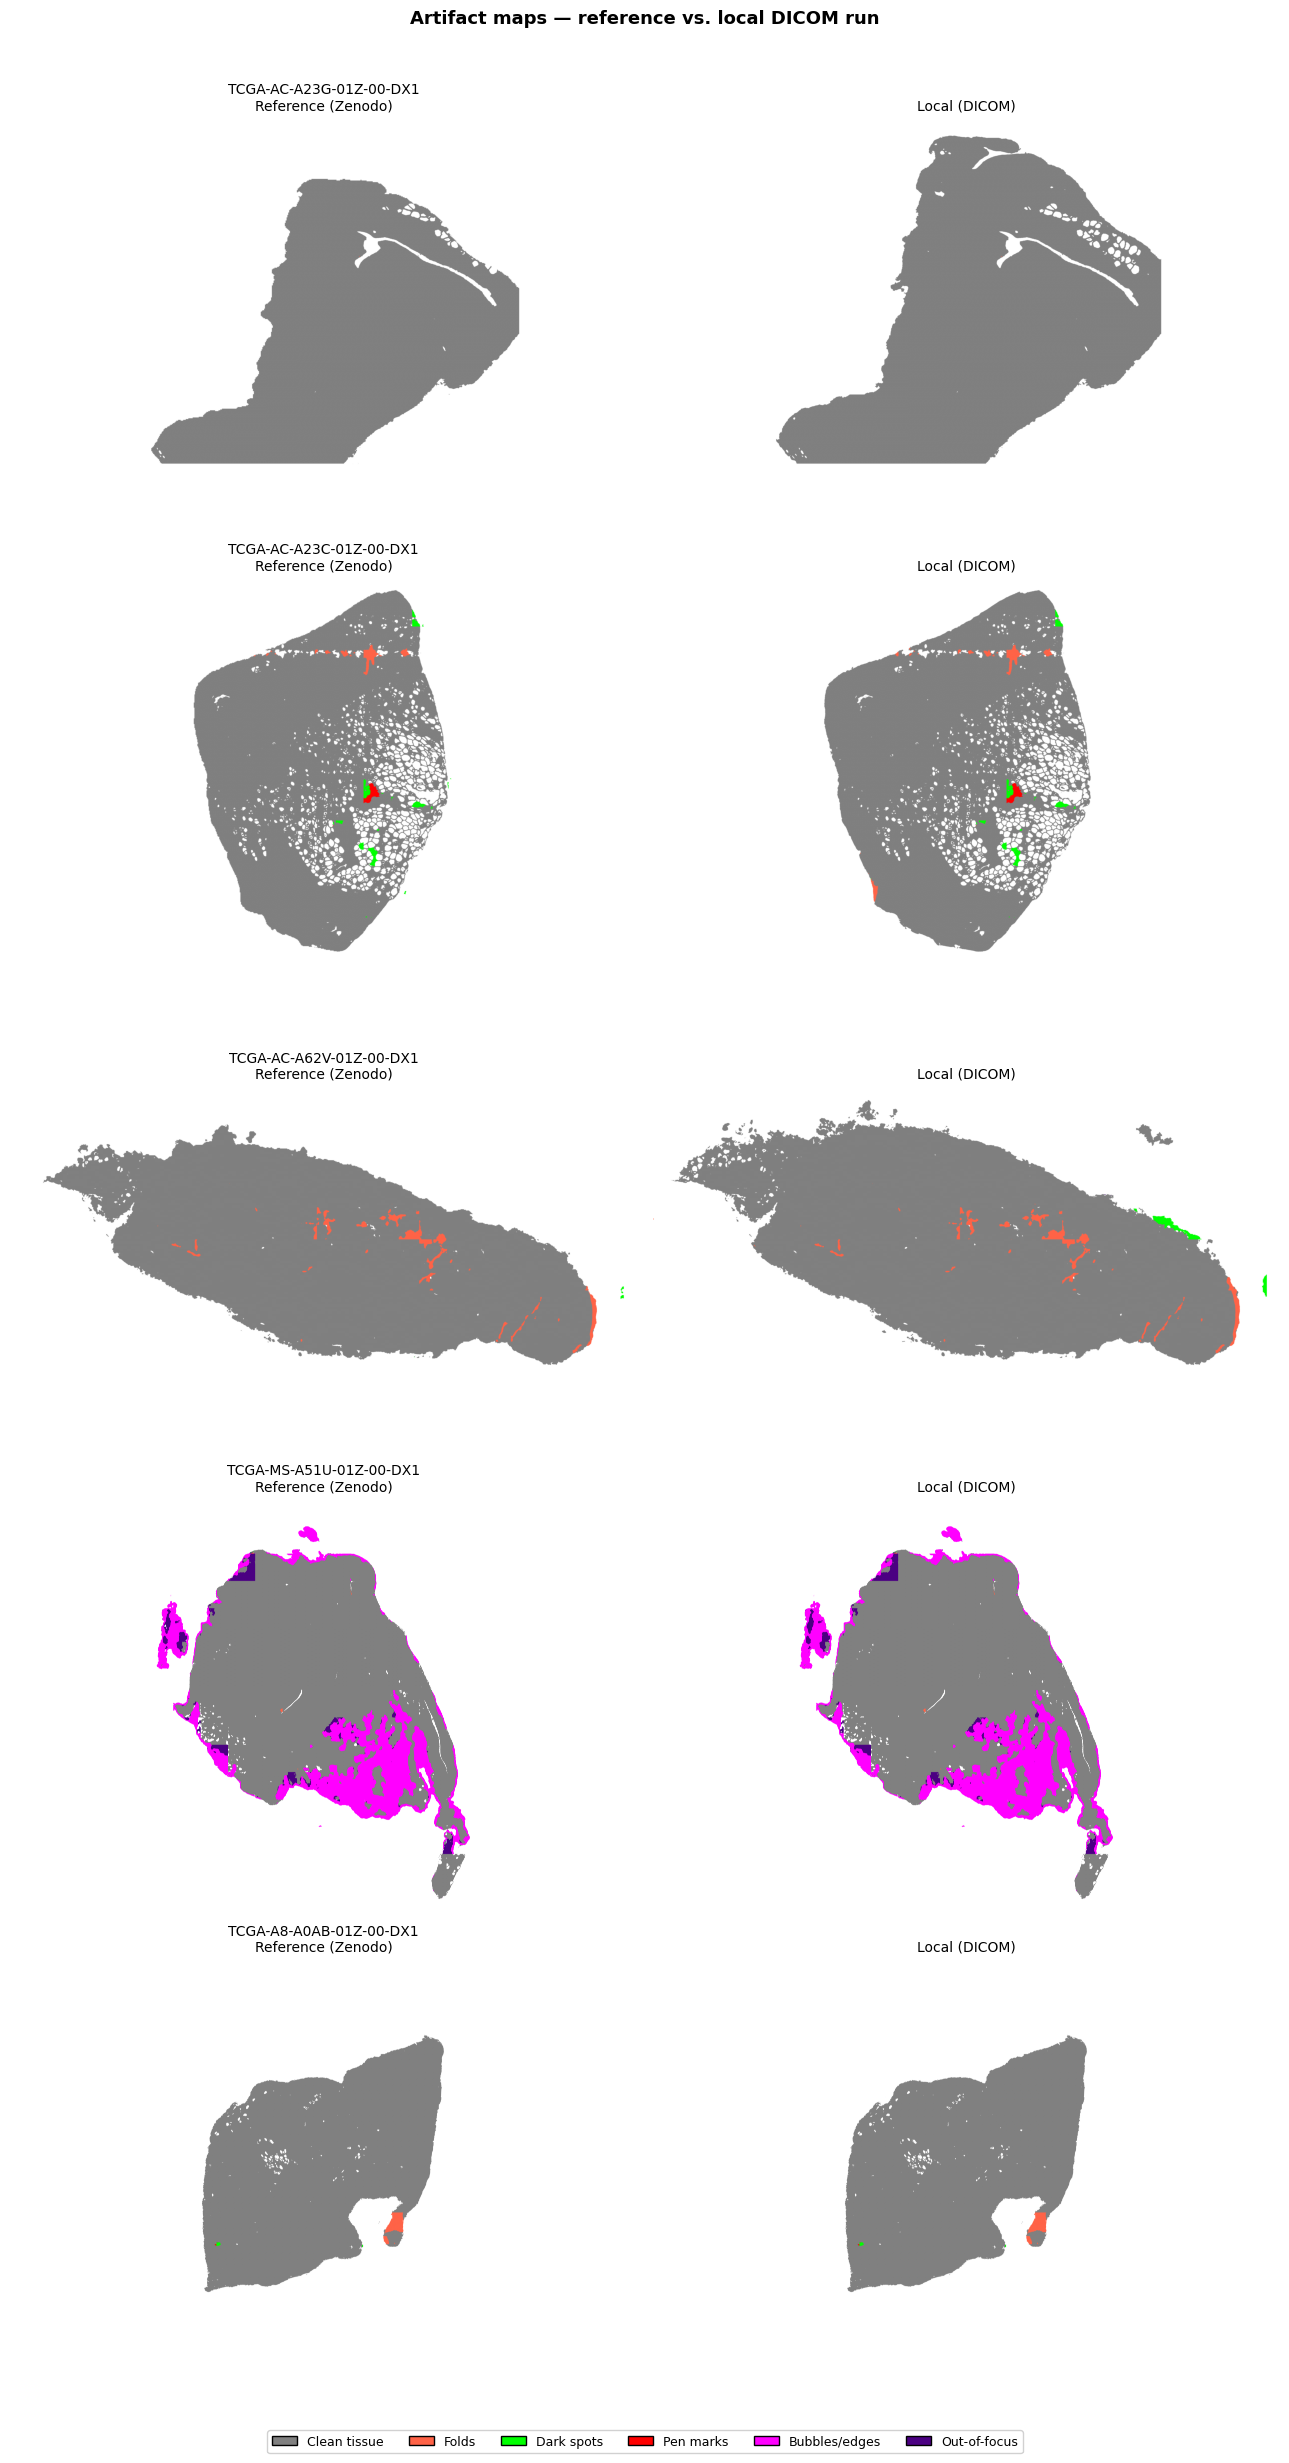

In [23]:
from matplotlib.patches import Patch

# Colour lookup for GrandQC class labels: 1-6 use the artifact palette, while
# 0 (padding) and 7 (background) are shown white.
palette = np.ones((8, 3))
for cls in range(1, 7):
    palette[cls] = mpl_colors[cls - 1]

def colorize(mask):
    return palette[np.clip(mask, 0, 7)]

slides = list(uid_to_barcode.values())
n = len(slides)
fig, axes = plt.subplots(n, 2, figsize=(13, 5.0 * n))
axes = np.atleast_2d(axes)

for row, barcode in enumerate(slides):
    local_path = os.path.join(OUTPUT_DIR, "mask_qc", f"{barcode}_mask.png")
    ref_fname  = ref_mask_by_barcode.get(barcode)
    ref_path   = os.path.join(REF_MASKS_DIR, ref_fname) if ref_fname else None

    ax_ref, ax_local = axes[row, 0], axes[row, 1]
    ax_ref.axis("off")
    ax_local.axis("off")

    if ref_path and os.path.exists(ref_path):
        ax_ref.imshow(colorize(np.array(Image.open(ref_path))))
    else:
        ax_ref.text(0.5, 0.5, "reference mask missing", ha="center", va="center")
    if os.path.exists(local_path):
        ax_local.imshow(colorize(np.array(Image.open(local_path))))
    else:
        ax_local.text(0.5, 0.5, "local mask missing", ha="center", va="center")

    ax_ref.set_title(f"{barcode}\nReference (Zenodo)", fontsize=10)
    ax_local.set_title("Local (DICOM)", fontsize=10)

# Shared legend of artifact classes
legend_handles = [Patch(facecolor=mpl_colors[i], edgecolor="black",
                        label=CLASS_NAMES_SHORT[i]) for i in range(len(CLASS_NAMES_SHORT))]
fig.legend(handles=legend_handles, loc="lower center", ncol=len(legend_handles),
           fontsize=9, framealpha=0.9, bbox_to_anchor=(0.5, 0.0))
plt.suptitle("Artifact maps — reference vs. local DICOM run", fontweight="bold", fontsize=13)
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

### 6.5 Scaling to Cohort-level QC

Because each reference mask is just a small PNG, the comparison above scales to an entire cohort. Downloading the full `BRCA.tar` (~2 GB) from the Zenodo record gives pre-computed masks for all 1,105 TCGA-BRCA diagnostic slides — enough to compute population-level artifact statistics (medians, percentiles, distributions) **without running any inference locally**. We keep this notebook lightweight by validating on the five demo slides only; the loop in section 6.3 generalizes directly to the full mask set, reading one mask at a time so memory stays constant.

## Part 7: Boundary-Anchored Edge Tiling (Optional Deep-Dive)

Parts 4–6 ran GrandQC exactly as published. Upstream GrandQC tiles each slide into full model patches using **floor division** and fills the leftover strip at the right and bottom edges — anything narrower than one patch — with a constant **background buffer**. That edge remainder is never shown to the model, so tissue and artifacts in the last (up to one-patch-wide) margin are reported as background.

An alternative is to **anchor** the edge patch: shift its read window back inside the slide so a *complete* patch is inferred at the boundary, then realign the prediction to the grid. This is the strategy used by the companion in-process GrandQC module; here we implement the same idea **on top of the exact Part 4 pipeline** — same wsidicom DICOM reader, same `GrandQC_MPP15` model, same MPP 1.5, same Step 1 tissue masks, same class labels — changing **only** the edge handling. Interior tiles are therefore inferred identically to Part 4; the two runs differ only along the slide edges.

Both strategies are described in detail, with code and a worked example, in [`grandqc_edge_tiling_notes.md`](grandqc_edge_tiling_notes.md).

> This part is an optional methodological deep-dive. It does **not** change the Part 4–6 results, which remain the faithful reproduction of upstream GrandQC.

### 7.1 Implement and Run the Boundary-Anchored Variant

We reuse the Part 4 **stock** artifact masks (`qc_output/mask_qc/`, from Step 2 / 4.2) unchanged for the slide interior and re-infer **only** the right/bottom edge remainder. Re-running the whole slide would let LANCZOS resizing and an independent tiling grid drift the interior away from the stock result; inheriting the interior byte-for-byte guarantees interior tiles are identical, so any difference in 7.2 is purely the edge handling.

For each edge cell, `_tile_read_origin` anchors the read window back to `extent − p_s` so a *complete* patch is inferred at the boundary (upstream drops that remainder into a background buffer). The `math.ceil` grid covers the edge column/row, and the anchored (back-shifted) prediction is realigned to its grid cell before being written over the inherited stock pixels. Masks are written to `qc_output/mask_qc_anchored/`, leaving the stock results in `qc_output/mask_qc/` intact.

> Runtime note: because only the edge band is recomputed (not the whole slide), this is much cheaper than a full Step 2 re-run; it reuses the already-loaded weights and the Part 4 stock masks.

In [24]:
# ── Boundary-anchored edge tiling ─────────────────────────────────────────────
# Re-run ONLY the artifact-segmentation stage (Part 4, Step 2) with a single
# change: the right/bottom edge remainder — which upstream GrandQC fills with a
# background buffer — is instead inferred from a boundary-anchored full patch.
# Everything else is identical to Part 4: wsidicom DICOM reading, the same
# GrandQC_MPP15 model, MPP 1.5, the Step 1 tissue masks, the per-tile tissue
# gate, and the class-label convention (argmax over channels). Interior tiles
# are therefore inferred identically to Part 4; the runs differ only at edges.
# See grandqc_edge_tiling_notes.md for the algorithm and a worked example.
import math
import sys
import torch
import segmentation_models_pytorch as smp
sys.path.insert(0, GRANDQC_SCRIPTS)   # the wsidicom-backed reader lives in the fork
from wsidicom_slide import WsiDicomSlide

MODEL_TILE_SIZE       = 512            # GrandQC model input side
MPP_MODEL             = 1.5            # artifact model resolution (matches Part 4)
BACK_CLASS            = 7              # GrandQC background class
ENCODER_MODEL         = "timm-efficientnet-b0"
ENCODER_MODEL_WEIGHTS = "imagenet"

DEVICE = (
    "cuda" if torch.cuda.is_available()
    else "mps" if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available()
    else "cpu"
)
print(f"Device: {DEVICE}")

# Same artifact model Part 4 used (weights_only=False for PyTorch >= 2.6).
qc_model = torch.load(
    os.path.join(MODELS_QC, "GrandQC_MPP15.pth"),
    map_location=DEVICE,
    weights_only=False,
)
_preprocessing_fn = smp.encoders.get_preprocessing_fn(ENCODER_MODEL, ENCODER_MODEL_WEIGHTS)


def _predict_tile(pil_tile):
    """GrandQC per-patch inference, identical to wsi_process.py: preprocess,
    predict, argmax over channels (no relabeling)."""
    arr = np.array(
        pil_tile.convert("RGB").resize((MODEL_TILE_SIZE, MODEL_TILE_SIZE),
                                        Image.Resampling.LANCZOS)
    )
    x = _preprocessing_fn(arr).transpose(2, 0, 1).astype("float32")
    x = torch.from_numpy(x).to(DEVICE).unsqueeze(0)
    pred = qc_model.predict(x).squeeze().cpu().numpy()
    return np.argmax(pred, axis=0).astype(np.uint8)


def _tile_read_origin(idx, p_s, extent):
    """Level-0 read start for grid cell `idx` along one axis, plus the cell's
    nominal origin. Interior cells use GrandQC's stock origin (idx*p_s, with its
    historical +1 offset for idx>0). An EDGE cell — whose full p_s window would
    run past `extent` — is anchored backwards to (extent - p_s) so a complete
    p_s window is read instead of dropped. Returns (read_start, nominal_x0)."""
    x0 = idx * p_s
    if x0 + p_s > extent:                        # edge cell -> anchor back
        return max(0, extent - p_s), x0
    return x0 + (1 if idx > 0 else 0), x0        # interior -> stock convention


def run_artifact_anchored(slide, mpp, stock_mask_png):
    """Boundary-anchored artifact mask that inherits the interior byte-for-byte
    from the Part 4.2 stock mask and re-infers ONLY the right/bottom edge
    remainder from a back-shifted full patch. Re-inferring the whole slide would
    let LANCZOS resizing and an independent grid drift the interior away from the
    stock result; inheriting it guarantees the interior tiles are identical."""
    full = np.array(Image.open(stock_mask_png)).copy()
    w_l0, h_l0 = slide.level_dimensions[0]
    p_s = int(MPP_MODEL / mpp * MODEL_TILE_SIZE)                 # native patch size

    # CEIL grid so the edge column/row is covered (stock uses floor + buffer).
    patch_n_w = max(1, math.ceil(w_l0 / p_s))
    patch_n_h = max(1, math.ceil(h_l0 / p_s))
    for he in range(patch_n_h):
        for wi in range(patch_n_w):
            x0, y0 = wi * p_s, he * p_s
            if (x0 + p_s <= w_l0) and (y0 + p_s <= h_l0):
                continue                                  # interior -> keep stock pixels
            r0, c0 = he * MODEL_TILE_SIZE, wi * MODEL_TILE_SIZE
            if r0 >= full.shape[0] or c0 >= full.shape[1]:
                continue                                  # grid cell beyond stock mask
            read_x, _ = _tile_read_origin(wi, p_s, w_l0)
            read_y, _ = _tile_read_origin(he, p_s, h_l0)
            raw = _predict_tile(slide.read_region((read_x, read_y), 0, (p_s, p_s)))

            # Realign the back-shifted (anchored) read to its grid cell; the strip
            # outside the slide stays background. off_x/off_y are 0 for interior.
            off_x = max(0, int(round((x0 - read_x) / p_s * MODEL_TILE_SIZE)))
            off_y = max(0, int(round((y0 - read_y) / p_s * MODEL_TILE_SIZE)))
            if off_x or off_y:
                aligned = np.full((MODEL_TILE_SIZE, MODEL_TILE_SIZE), BACK_CLASS, np.uint8)
                aligned[:MODEL_TILE_SIZE - off_y, :MODEL_TILE_SIZE - off_x] = raw[off_y:, off_x:]
                raw = aligned

            he_ = min(MODEL_TILE_SIZE, full.shape[0] - r0)
            wi_ = min(MODEL_TILE_SIZE, full.shape[1] - c0)
            full[r0:r0 + he_, c0:c0 + wi_] = raw[:he_, :wi_]
    return full


# Run on the demo slides; write to a separate folder so Part 4's stock masks in
# qc_output/mask_qc/ are left intact for the comparison in 7.2. The interior is
# inherited from those stock masks, so only the edge band is recomputed here.
ANCHORED_DIR = os.path.join(OUTPUT_DIR, "mask_qc_anchored")
os.makedirs(ANCHORED_DIR, exist_ok=True)

for barcode in uid_to_barcode.values():
    slide_folder = os.path.join(SLIDE_DIR, barcode)
    dcm = sorted(f for f in os.listdir(slide_folder) if f.lower().endswith(".dcm"))
    stock_png = os.path.join(OUTPUT_DIR, "mask_qc", f"{barcode}_mask.png")
    if not dcm or not os.path.exists(stock_png):
        print(f"  skip {barcode} (missing slide or stock mask)")
        continue
    slide = WsiDicomSlide(os.path.join(slide_folder, dcm[0]))
    mpp = float(slide.properties["openslide.mpp-x"])
    mask = run_artifact_anchored(slide, mpp, stock_png)
    slide.close()
    Image.fromarray(mask).save(os.path.join(ANCHORED_DIR, f"{barcode}_mask.png"))
    print(f"  {barcode}: {mask.shape[1]}×{mask.shape[0]} boundary-anchored mask written")

print(f"\nBoundary-anchored masks written to {ANCHORED_DIR}/")

Device: cuda
  TCGA-AC-A23G-01Z-00-DX1: 3263×3037 boundary-anchored mask written
  TCGA-AC-A23C-01Z-00-DX1: 3263×4328 boundary-anchored mask written
  TCGA-AC-A62V-01Z-00-DX1: 6286×3145 boundary-anchored mask written
  TCGA-MS-A51U-01Z-00-DX1: 6653×7688 boundary-anchored mask written
  TCGA-A8-A0AB-01Z-00-DX1: 5515×6626 boundary-anchored mask written

Boundary-anchored masks written to qc_output/mask_qc_anchored/


### 7.2 Stock vs. Boundary-Anchored: Where They Differ

For each slide we show the stock artifact mask (left), the boundary-anchored mask (middle), and a disagreement map (right). Because interior tiles are inferred identically, disagreement is concentrated in the right/bottom edge band that the stock run fills with background. The table quantifies how many tissue/artifact pixels the anchored run recovers in that band.

The size of the effect depends on how far the slide's dimensions fall from an exact multiple of the native patch size: a slide that ends just after a patch boundary loses only a thin strip, while one that ends just before the next boundary loses a band nearly a full patch wide.

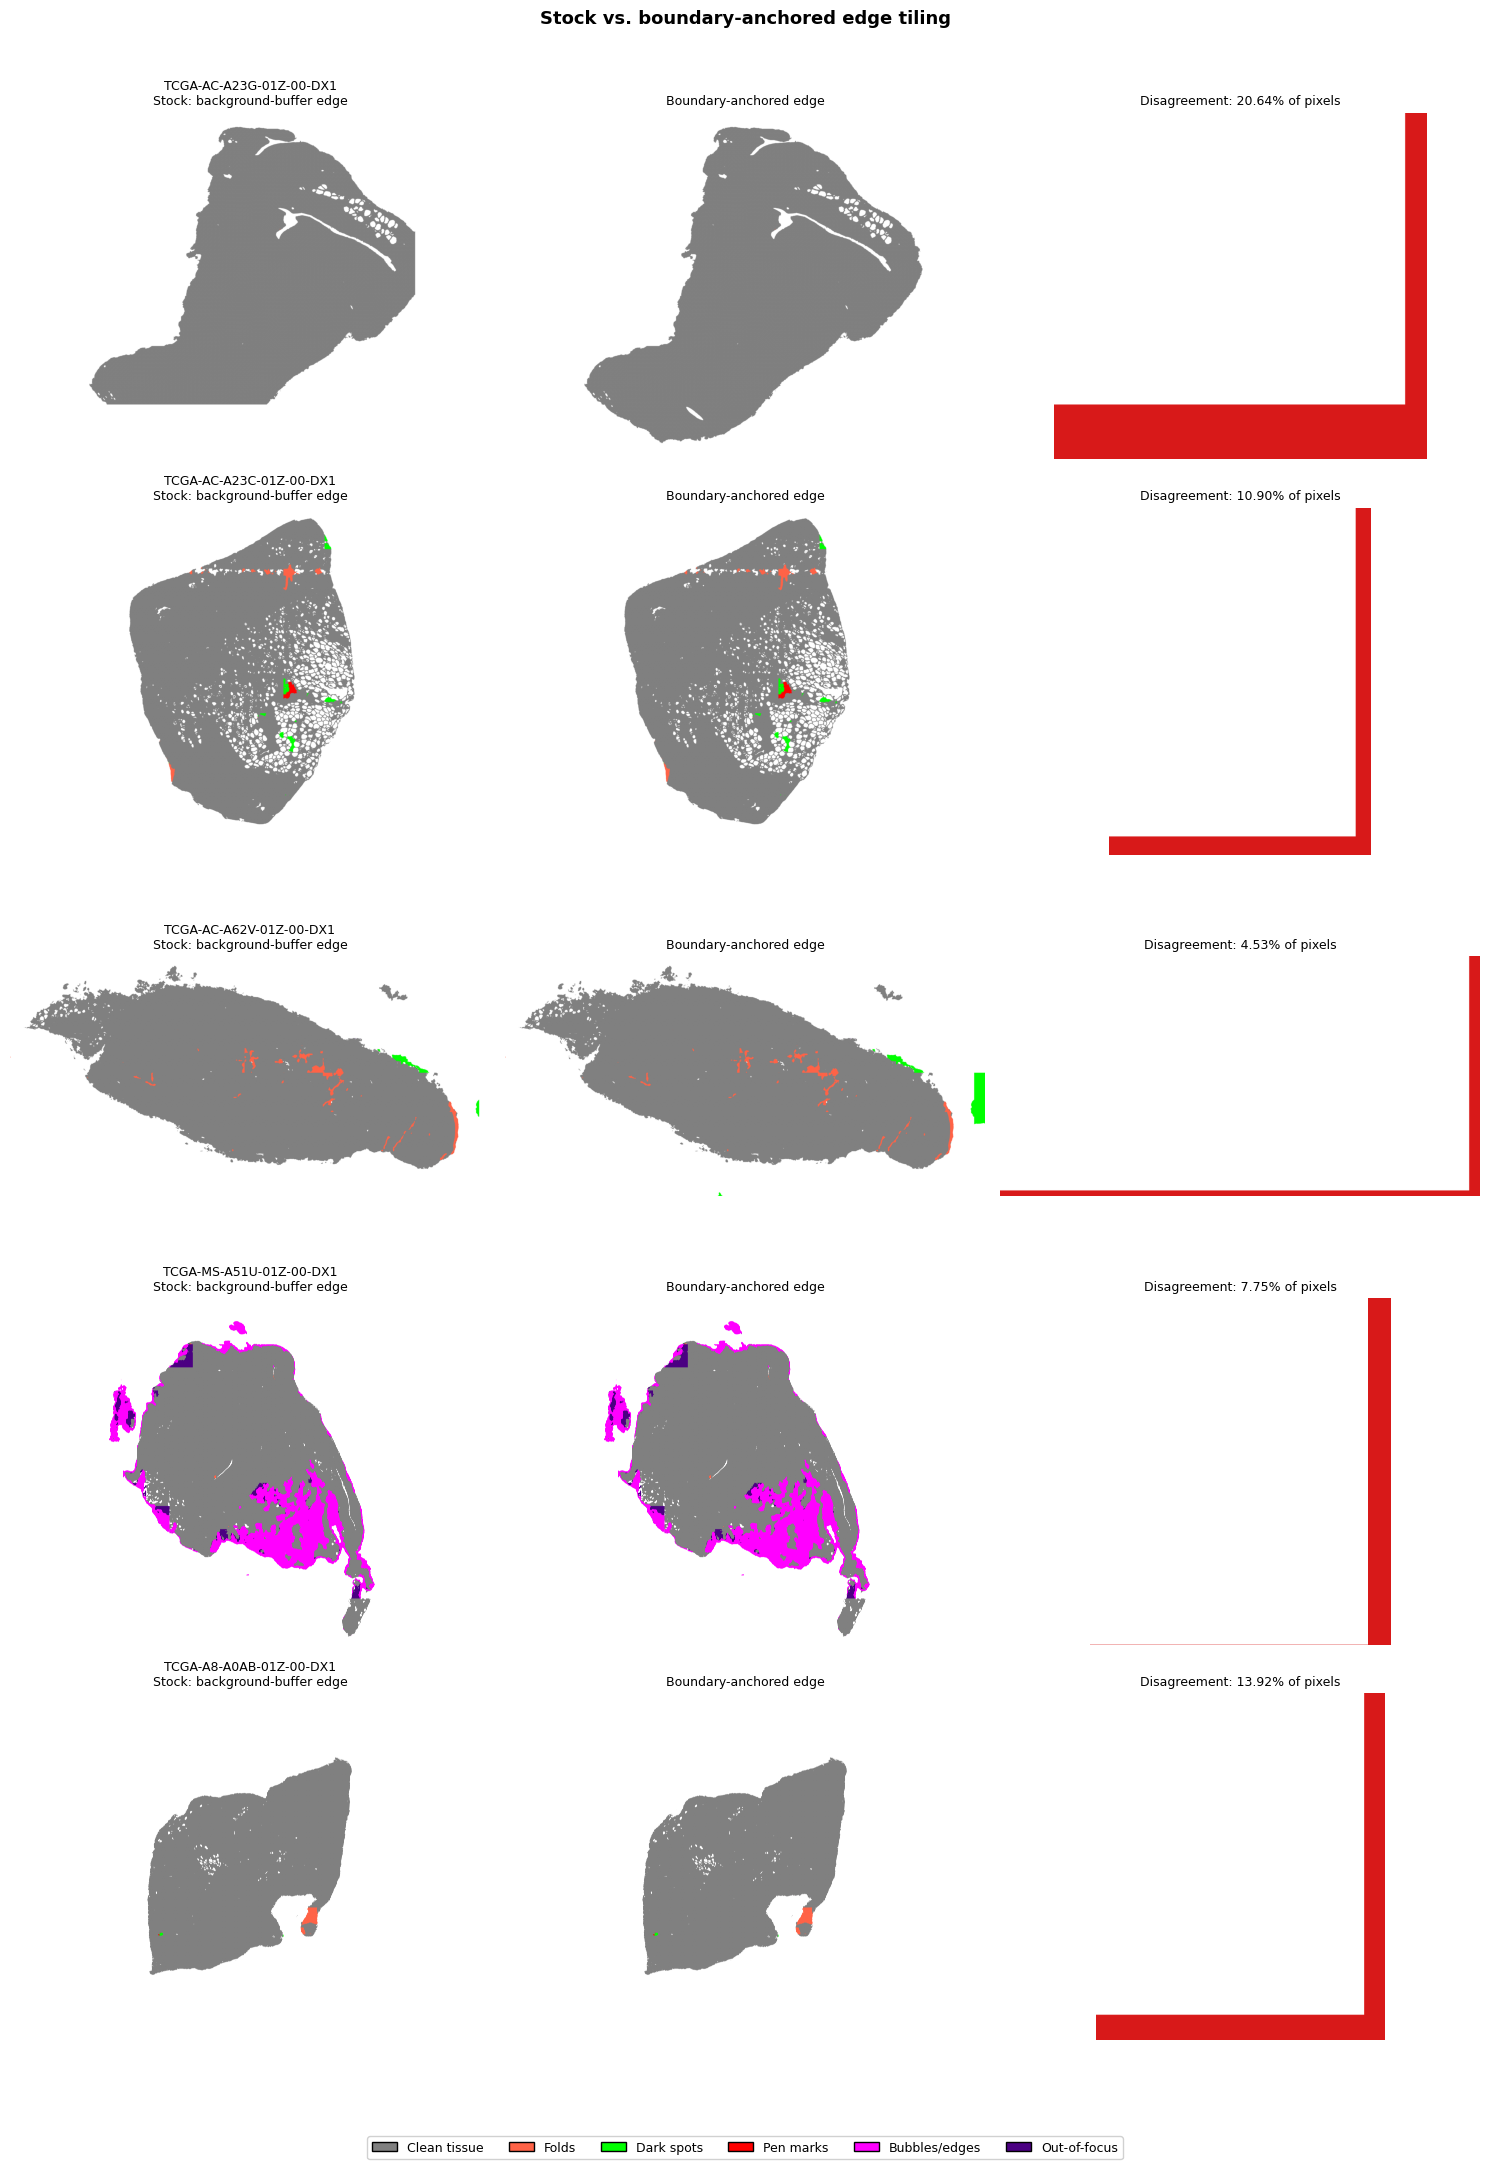

Tissue/artifact pixels the stock run left as background that boundary
anchoring recovers (concentrated in the right/bottom edge band):



,disagree_%,edge_px_recovered,recovered_%_of_tissue
slide,,,
TCGA-AC-A23G-01Z-00-DX1,20.640,328913,8.016
TCGA-AC-A23C-01Z-00-DX1,10.900,0,0.000
TCGA-AC-A62V-01Z-00-DX1,4.528,95651,1.136
TCGA-MS-A51U-01Z-00-DX1,7.747,1,0.000
TCGA-A8-A0AB-01Z-00-DX1,13.916,0,0.000


In [25]:
from matplotlib.patches import Patch

# Stock (Part 4) vs boundary-anchored (7.1). Interior tiles are inferred
# identically, so disagreement is concentrated in the right/bottom edge band
# that the stock run fills with background.
barcodes = list(uid_to_barcode.values())
n = len(barcodes)
fig, axes = plt.subplots(n, 3, figsize=(15, 4.4 * n))
axes = np.atleast_2d(axes)

NON_BACKGROUND = [1, 2, 3, 4, 5, 6]           # clean tissue + 5 artifact classes
rows = []
for r, barcode in enumerate(barcodes):
    stock_path    = os.path.join(OUTPUT_DIR, "mask_qc", f"{barcode}_mask.png")
    anchored_path = os.path.join(ANCHORED_DIR, f"{barcode}_mask.png")
    ax_s, ax_a, ax_d = axes[r]
    for ax in (ax_s, ax_a, ax_d):
        ax.axis("off")
    if not (os.path.exists(stock_path) and os.path.exists(anchored_path)):
        ax_s.text(0.5, 0.5, f"{barcode}\nmask missing", ha="center", va="center")
        continue

    stock    = np.array(Image.open(stock_path))
    anchored = np.array(Image.open(anchored_path))
    h = min(stock.shape[0], anchored.shape[0])      # crop to common extent
    w = min(stock.shape[1], anchored.shape[1])       # (can differ by a pixel)
    stock, anchored = stock[:h, :w], anchored[:h, :w]

    ax_s.imshow(colorize(stock))
    ax_s.set_title(f"{barcode}\nStock: background-buffer edge", fontsize=9)
    ax_a.imshow(colorize(anchored))
    ax_a.set_title("Boundary-anchored edge", fontsize=9)

    diff = stock != anchored
    dimg = np.ones((h, w, 3))
    dimg[diff] = [0.85, 0.10, 0.10]
    ax_d.imshow(dimg)
    ax_d.set_title(f"Disagreement: {diff.mean() * 100:.2f}% of pixels", fontsize=9)

    recovered = int(np.sum(np.isin(stock, [0, BACK_CLASS]) & np.isin(anchored, NON_BACKGROUND)))
    tissue_anchored = int(np.sum(np.isin(anchored, NON_BACKGROUND)))
    rows.append({
        "slide":                 barcode,
        "disagree_%":            round(diff.mean() * 100, 3),
        "edge_px_recovered":     recovered,
        "recovered_%_of_tissue": round(recovered / tissue_anchored * 100, 3) if tissue_anchored else 0.0,
    })

legend_handles = [Patch(facecolor=mpl_colors[i], edgecolor="black", label=CLASS_NAMES_SHORT[i])
                  for i in range(len(CLASS_NAMES_SHORT))]
fig.legend(handles=legend_handles, loc="lower center", ncol=len(CLASS_NAMES_SHORT),
           fontsize=9, framealpha=0.9, bbox_to_anchor=(0.5, 0.0))
plt.suptitle("Stock vs. boundary-anchored edge tiling", fontweight="bold", fontsize=13)
plt.tight_layout(rect=[0, 0.05, 1, 0.97])
plt.show()

recovery_df = pd.DataFrame(rows).set_index("slide")
print("Tissue/artifact pixels the stock run left as background that boundary")
print("anchoring recovers (concentrated in the right/bottom edge band):\n")
display(recovery_df)

### 7.3 Inspect the Recovered Edge Tissue: Real, or a Seam Artifact?

The 7.2 table counts pixels the anchored run marks as tissue/artifact where the stock run had background. That count is only meaningful if those pixels are **genuine tissue** recovered at the slide edge — not a misclassified stripe introduced by the anchored-tile realignment. Below we pull the original slide pixels under each recovered region and view them next to the recovered mask. Real dark-stained tissue on the left panel confirms the recovery is correct and the edge count is a genuine improvement; slide background, or a clean tile with a stripe along the seam, would instead point to a bug in the `off_x` / `off_y` realignment in 7.1.

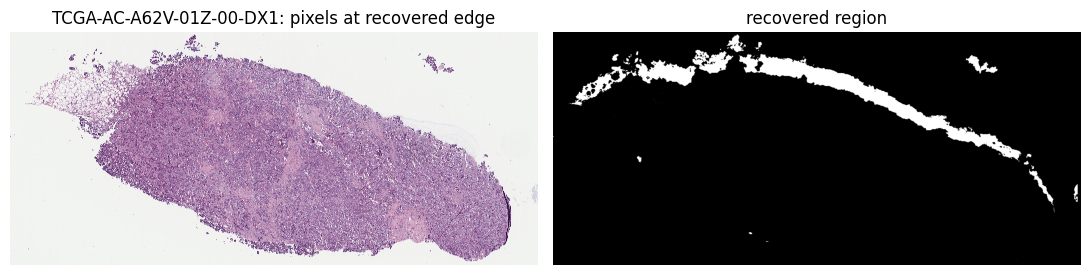

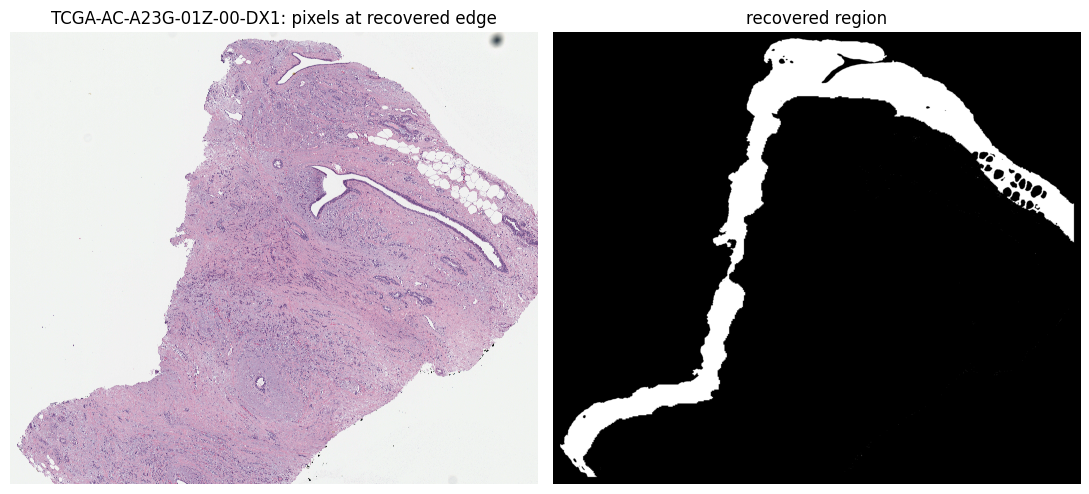

In [27]:
from PIL import Image

Image.MAX_IMAGE_PIXELS = None # Disable decompression bomb check for large images

def inspect_recovered(barcode, pad=40):
    ref = np.array(Image.open(os.path.join(REF_MASKS_DIR, ref_mask_by_barcode[barcode])))
    loc = np.array(Image.open(os.path.join(ANCHORED_DIR, f"{barcode}_mask.png")))
    if ref.shape != loc.shape:
        ref = np.array(Image.fromarray(ref).resize(loc.shape[::-1], Image.Resampling.NEAREST))
    rec = (loc != BACK) & (ref == BACK)
    if not rec.any():
        print(f"{barcode}: nothing recovered"); return
    ys, xs = np.where(rec)
    y0, y1 = max(0, ys.min()-pad), ys.max()+pad
    x0, x1 = max(0, xs.min()-pad), xs.max()+pad
    slide_folder = os.path.join(SLIDE_DIR, barcode)
    dcm = sorted(f for f in os.listdir(slide_folder) if f.lower().endswith(".dcm"))[0]
    slide = WsiDicomSlide(os.path.join(slide_folder, dcm))
    s = MPP_MODEL / float(slide.properties["openslide.mpp-x"])   # mask px -> level-0 px
    rgb = slide.read_region((int(x0*s), int(y0*s)), 0,
                            (int((x1-x0)*s), int((y1-y0)*s))).convert("RGB")
    slide.close()
    fig, ax = plt.subplots(1, 2, figsize=(11, 5))
    ax[0].imshow(rgb);                            ax[0].set_title(f"{barcode}: pixels at recovered edge")
    ax[1].imshow(rec[y0:y1, x0:x1], cmap="gray"); ax[1].set_title("recovered region")
    for a in ax: a.axis("off")
    plt.tight_layout(); plt.show()

for bc in ["TCGA-AC-A62V-01Z-00-DX1", "TCGA-AC-A23G-01Z-00-DX1"]:
    inspect_recovered(bc)